# Análisis FBG: Fibra DW-3 "Suelta" — Sensores + Media Polarizaciones (01/07/2026)

## 🔬 Setup experimental

Este notebook analiza la fibra **DW-3** en una configuración nueva:

- **Fibra "suelta"**: sin tubo PTFE protector y sin peso al final de la fibra.
- **1 solo RTD en cápsula**: RTD-8 (índice 7). Ya no están el RTD-7 y RTD-8 simultáneamente como en medidas anteriores.
- **FBGs**: Se espera que la fibra DW-3 tenga hasta 5 sensores FBG, pero en la medida del 20260202 el 5º FBG (FBG-4 con indexación 0) estaba en una longitud de onda al **límite del rango del interrogador** y no se pudo analizar. Se sospecha que la fibra pueda estar rota y el último FBG no sea visible en el espectro. Analizaremos el FBG 4 que es el que está más cerca del RTD. (aunque debería estarlo más)

### 📋 Objetivos de este análisis:
1. **Investigar el espectro** (rama del tree `peak`): ¿Se ven 5 picos o solo 4?
2. **Comparar cada sensor FBG con el RTD de la cápsula** (RTD-8, índice 7) mediante plots superpuestos de temperatura vs longitud de onda.
3. Identificar qué sensor FBG está más cercano al RTD y correlaciona mejor.

### ⚠️ Notas importantes:
- **Comparación con 20260202**: En aquella fecha, la fibra DW-3 se analizó sin tubo PTFE y sin peso (enrollada cerca del RTD). Solo 3 de los 4 FBGs configurados fueron funcionales (FBG-4 omitido por estar al límite del rango del interrogador).
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, **7 = cápsula fibra (único)**
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

### 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.


In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])


Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot





### 🔍 Listar Archivos Disponibles (Opcional)



In [3]:
from zoneinfo import ZoneInfo
TZ_VALENCIA = ZoneInfo("Europe/Madrid")

# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260701.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# NOTA: Ajustar este valor tras inspeccionar los datos
TIME_SHIFT = datetime.timedelta(hours=0)  # ⚠️ A AJUSTAR — inspeccionar desfase

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        
        # Intentar cargar presión (puede no existir en este dataset)
        try:
            press_data = file["press"].arrays(library="np")
            press_raw = press_data["press"]
            has_press = True
            print("✓ Datos de presión encontrados")
        except Exception:
            has_press = False
            press_data = None
            press_raw = None
            print("⚠️  No hay datos de presión en este dataset")
    
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    
    # 🔍 Diagnóstico del número de sensores FBG
    n_fbg_sensors = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
    print(f"\n🔍 NÚMERO DE SENSORES FBG DETECTADOS: {n_fbg_sensors}")
    print(f"   (Shape wav_raw: {wav_raw.shape})")
    if n_fbg_sensors == 4:
        print("   → Se detectan 4 picos en el espectro")
    elif n_fbg_sensors == 3:
        print("   → Se detectan solo 3 picos — ¿fibra rota? ¿5º FBG no visible?")
    else:
        print(f"   → Se detectan {n_fbg_sensors} picos")
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260701.root
⏱️  TIME_SHIFT configurado: 0.0 horas
✓ Trees disponibles: ['peak;6', 'press;3', 'spectrum;2', 'temp;2']


✓ Datos de presión encontrados

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (1365250, 2)
   wav: shape = (1365250, 2, 5)
   sweep: shape = (1365250, 2, 5)
   ch: shape = (1365250, 5)
   pos: shape = (1365250, 5)

🔍 NÚMERO DE SENSORES FBG DETECTADOS: 5
   (Shape wav_raw: (1365250, 2, 5))
   → Se detectan 5 picos

✅ Datos cargados correctamente
   • Wavelength: (1365250, 2, 5)
   • Wavelength range: [1543.34, 1560.49] nm
   • Temperature: (4877, 7)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-07-01 12:46:51
   Fin:    2026-07-01 16:04:55

🔴 TEMPERATURA:
   Inicio: 2026-07-01 13:40:54
   Fin:    2026-07-01 16:04:45

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +0.90 horas
   Temperatura END - Wavelength END: -0.00 horas

💡 RECOMENDACIÓN:
   Los datos parecen tener un desfase temporal.
   Prueba: TIME_SHIFT = datetime.timedelta(hours=1)
   Luego re-ejecuta esta celda.


### 📊 Visualización rápida de Presión



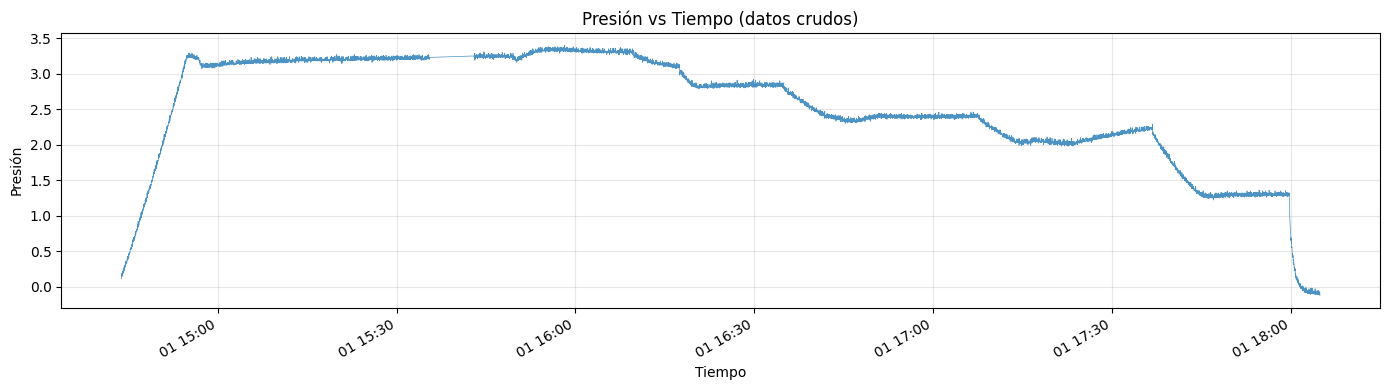

In [4]:
# Plot simple de presión vs tiempo (si los datos existen)
if has_press:
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    
    # Extraer tiempos de presión y datos
    times_press_raw = press_data["t"]
    times_press = np.array([datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None) for t in times_press_raw])
    
    # Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
    if len(press_raw.shape) > 1:
        press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
    else:
        press_data_plot = press_raw
    
    ax.plot(times_press, press_data_plot, linewidth=0.5, alpha=0.8)
    ax.set_ylabel('Presión')
    ax.set_xlabel('Tiempo')
    ax.set_title('Presión vs Tiempo (datos crudos)')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No hay datos de presión disponibles en este dataset. Saltando esta celda.")

In [5]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Fecha del ensayo (necesaria para plateaus y filtros)
fecha = datetime.date(2026, 7, 1)  # ⬅️ CAMBIAR según tu archivo (20260701.root)

# Opción A: Usar TODO el rango disponible
use_full_range = True  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    t_inicio = datetime.datetime.combine(fecha, datetime.time(14, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(16, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")


📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-07-01 12:46:51
   Fin:    2026-07-01 16:04:55

✅ Rango seleccionado para análisis:
   2026-07-01 12:46 - 16:04
   Puntos en el rango: 1,365,249


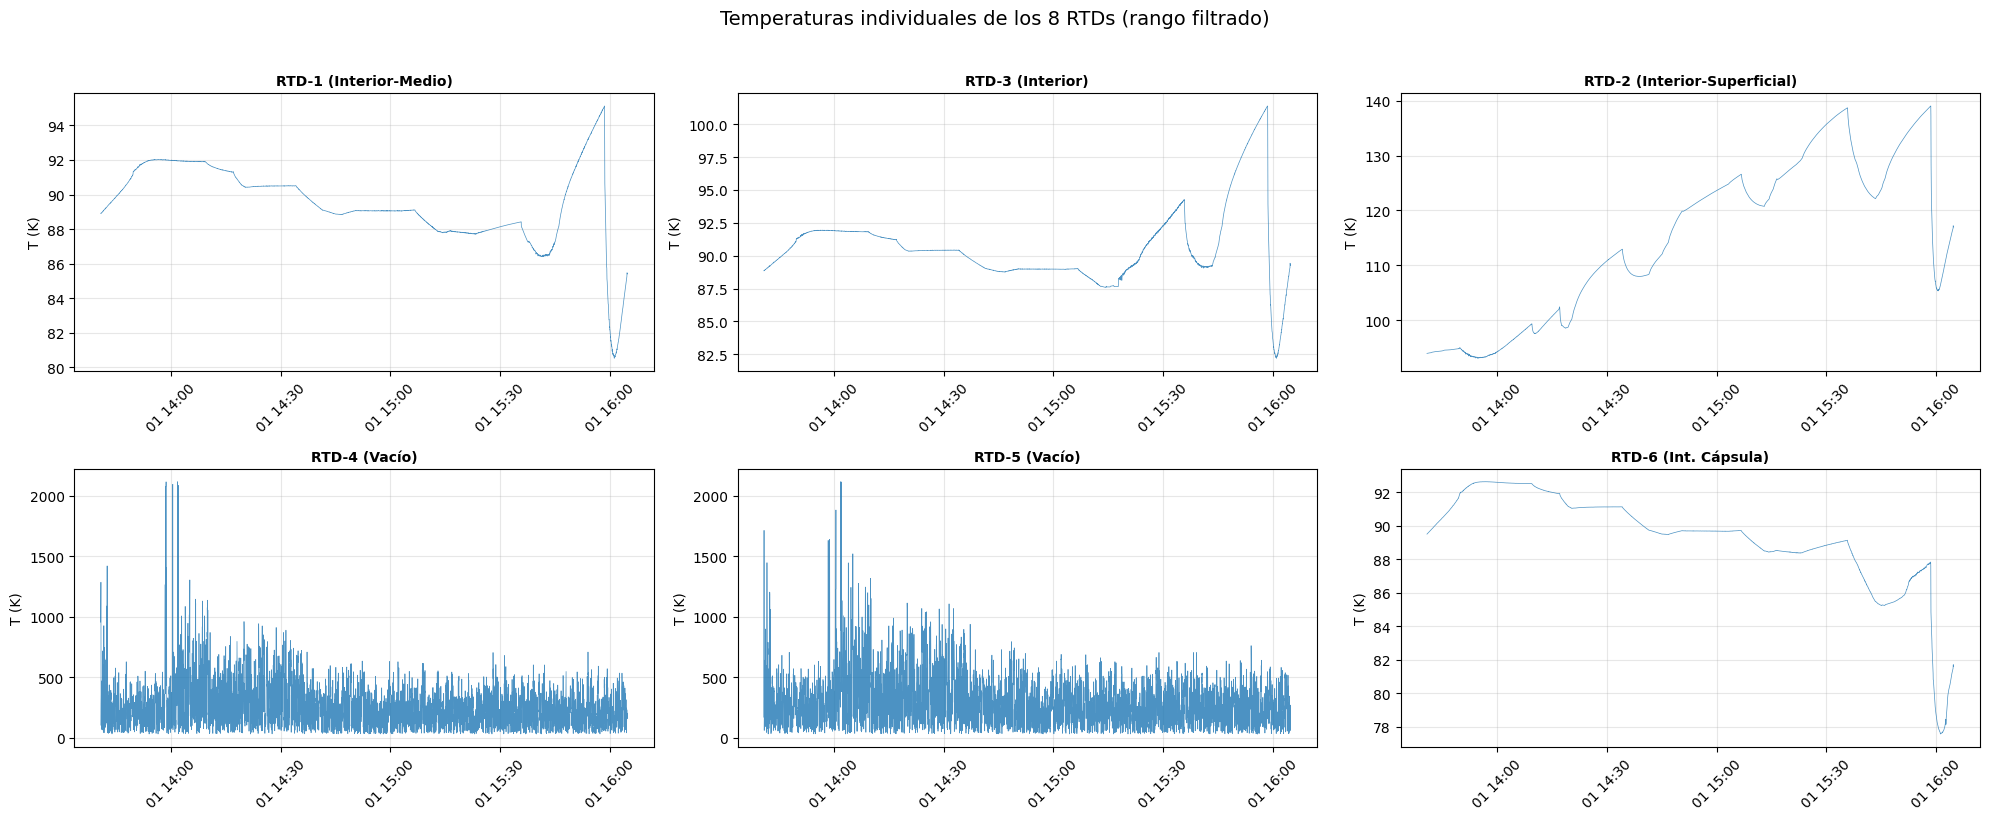


📌 NOTA: En este setup solo RTD-7 (índice 7) está en la cápsula de la fibra.


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-1 (Interior-Medio)"),          # Medio
    (2, "RTD-3 (Interior)"),                # Siguiente altura
    (1, "RTD-2 (Interior-Superficial)"),    # Más externo/superficial
    (3, "RTD-4 (Vacío)"),                   # Vacío
    (4, "RTD-5 (Vacío)"),                   # Vacío
    (5, "RTD-6 (Int. Cápsula)"),            # ✅ ÚNICO RTD en cápsula de fibra
]

n_rtds = len(rtd_sensors_ordered)

# Layout: 2 filas x 4 columnas
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for plot_idx, (rtd_idx, rtd_name) in enumerate(rtd_sensors_ordered):
    ax = axes[plot_idx]
    temp_sensor = temp_filtered[:, rtd_idx]
    mask_valid = temp_sensor > 0
    
    ax.plot(times_temp_filtered[mask_valid], temp_sensor[mask_valid], 
            linewidth=0.5, alpha=0.8)
    ax.set_title(rtd_name, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    if mask_valid.sum() > 0:
        ax.set_ylabel('T (K)')
    else:
        ax.text(0.5, 0.5, 'Sin datos', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='red')

plt.suptitle('Temperaturas individuales de los 8 RTDs (rango filtrado)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 NOTA: En este setup solo RTD-7 (índice 7) está en la cápsula de la fibra.")


## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de Sensores FBG

⚠️ **NOTA**: La fibra DW-3 puede tener hasta 5 FBGs, pero en el análisis del 20260202 el 5º FBG (FBG-5/índice 4) estaba en una longitud de onda **al límite del rango del interrogador**, por lo que no se pudo analizar. Ahora, con la fibra suelta (sin PTFE ni peso), se sospecha que podría estar rota y el último FBG no sea visible.



In [7]:
# ⚠️ CONFIGURACIÓN: Detectar sensores automáticamente según los datos cargados
# La fibra DW-3 tiene hasta 5 FBGs, pero el interrogador puede no ver todos
# En 20260202: solo 3 de 4 sensores fueron funcionales (FBG-4 omitido)
# Ahora (fibra suelta, sin PTFE): ¿4 picos? ¿5? ¿Solo 3?

n_fbg_total = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
print(f"📊 El archivo ROOT contiene {n_fbg_total} sensores FBG (canales)")

# Detectar sensores con datos válidos (wavelength > 0)
fbg_config = []
active_sensors = []

for sensor_idx in range(n_fbg_total):
    # Verificar si el sensor tiene datos positivos
    wav_sensor_p = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_sensor_s = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    has_data_p = np.sum(wav_sensor_p > 0) > 100  # Al menos 100 puntos válidos
    has_data_s = np.sum(wav_sensor_s > 0) > 100
    
    sensor_num = sensor_idx + 1  # 1-based para labels
    
    if has_data_p and has_data_s:
        fbg_config.append({"pol": 0, "sensor": sensor_idx, "label": f"FBG-{sensor_num}-P"})
        fbg_config.append({"pol": 1, "sensor": sensor_idx, "label": f"FBG-{sensor_num}-S"})
        active_sensors.append(sensor_num)
        wav_range_p = f"[{np.min(wav_sensor_p[wav_sensor_p>0]):.2f}, {np.max(wav_sensor_p):.2f}]"
        wav_range_s = f"[{np.min(wav_sensor_s[wav_sensor_s>0]):.2f}, {np.max(wav_sensor_s):.2f}]"
        print(f"  ✅ FBG-{sensor_num}: ACTIVO (P: {wav_range_p} nm, S: {wav_range_s} nm)")
    else:
        status_p = '✅' if has_data_p else '❌'
        status_s = '✅' if has_data_s else '❌'
        print(f"  ⚠️  FBG-{sensor_num}: OMITIDO (P: {status_p}, S: {status_s})")

print(f"\n✅ Configurados {len(fbg_config)} canales FBG ({len(active_sensors)} sensores × 2 polarizaciones)")
print(f"   Sensores activos: {active_sensors}")
if len(active_sensors) < n_fbg_total:
    omitted = [i+1 for i in range(n_fbg_total) if (i+1) not in active_sensors]


📊 El archivo ROOT contiene 5 sensores FBG (canales)
  ✅ FBG-1: ACTIVO (P: [1543.34, 1543.68] nm, S: [1543.35, 1543.69] nm)
  ✅ FBG-2: ACTIVO (P: [1549.03, 1549.47] nm, S: [1549.04, 1549.47] nm)
  ✅ FBG-3: ACTIVO (P: [1554.76, 1555.07] nm, S: [1554.76, 1555.07] nm)
  ✅ FBG-4: ACTIVO (P: [1560.41, 1560.48] nm, S: [1560.41, 1560.49] nm)
  ⚠️  FBG-5: OMITIDO (P: ❌, S: ❌)

✅ Configurados 8 canales FBG (4 sensores × 2 polarizaciones)
   Sensores activos: [1, 2, 3, 4]


In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1, 2)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):")
for sensor_idx in range(3):  # Solo 0, 1, 2 (FBG-4 omitido)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (1365249, 2, 5)
   Dimensiones: (time=1365249, pol=2, sensor=5)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):
   FBG-1-P: 1359060 pts > 0, range=[1543.34, 1543.68] nm, μ=1543.60 nm
   FBG-1-S: 1360659 pts > 0, range=[1543.35, 1543.69] nm, μ=1543.60 nm
   FBG-2-P: 1365249 pts > 0, range=[1549.03, 1549.47] nm, μ=1549.37 nm


   FBG-2-S: 1365249 pts > 0, range=[1549.04, 1549.47] nm, μ=1549.37 nm
   FBG-3-P: 1364022 pts > 0, range=[1554.76, 1555.07] nm, μ=1554.90 nm
   FBG-3-S: 1365249 pts > 0, range=[1554.76, 1555.07] nm, μ=1554.91 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1543.595988  0.042857     1340162
FBG-1-S      1543.597420  0.045632     1341385
FBG-2-P      1549.368883  0.057121     1342578
FBG-2-S      1549.372739  0.056548     1343099
FBG-3-P      1554.902994  0.078740     1364022
FBG-3-S      1554.905786  0.075586     1365249
FBG-4-P      1560.456910  0.020422     1365249
FBG-4-S      1560.462956  0.022355     1365249


In [9]:
# Calcular media P+S para cada sensor activo
fbg_mean_data = {}

for sensor_num in active_sensors:  # Solo sensores detectados como activos
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Interpolar para alinear ambas polarizaciones
    # Usar timestamps de P como referencia
    from scipy import interpolate
    
    # Convertir timestamps a numéricos para interpolación
    times_p_num = np.array([t.timestamp() for t in times_p])
    times_s_num = np.array([t.timestamp() for t in times_s])
    
    # Interpolar S sobre los tiempos de P
    f_interp = interpolate.interp1d(times_s_num, wav_s, kind='linear', 
                                     bounds_error=False, fill_value=np.nan)
    wav_s_interp = f_interp(times_p_num)
    
    # Calcular media punto a punto
    wav_mean = (wav_p + wav_s_interp) / 2
    
    # Eliminar NaN
    mask_valid = ~np.isnan(wav_mean)
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p[mask_valid],
        "wavelength": wav_mean[mask_valid],
        "sensor_num": sensor_num
    }
    
    print(f"✅ {label_mean}: {mask_valid.sum()} puntos válidos, "
          f"rango [{np.nanmin(wav_mean[mask_valid]):.3f}, {np.nanmax(wav_mean[mask_valid]):.3f}] nm")



✅ FBG-1-Mean: 1340162 puntos válidos, rango [1543.467, 1543.685] nm
✅ FBG-2-Mean: 1342578 puntos válidos, rango [1549.201, 1549.468] nm
✅ FBG-3-Mean: 1364022 puntos válidos, rango [1554.763, 1555.071] nm
✅ FBG-4-Mean: 1365249 puntos válidos, rango [1560.409, 1560.484] nm


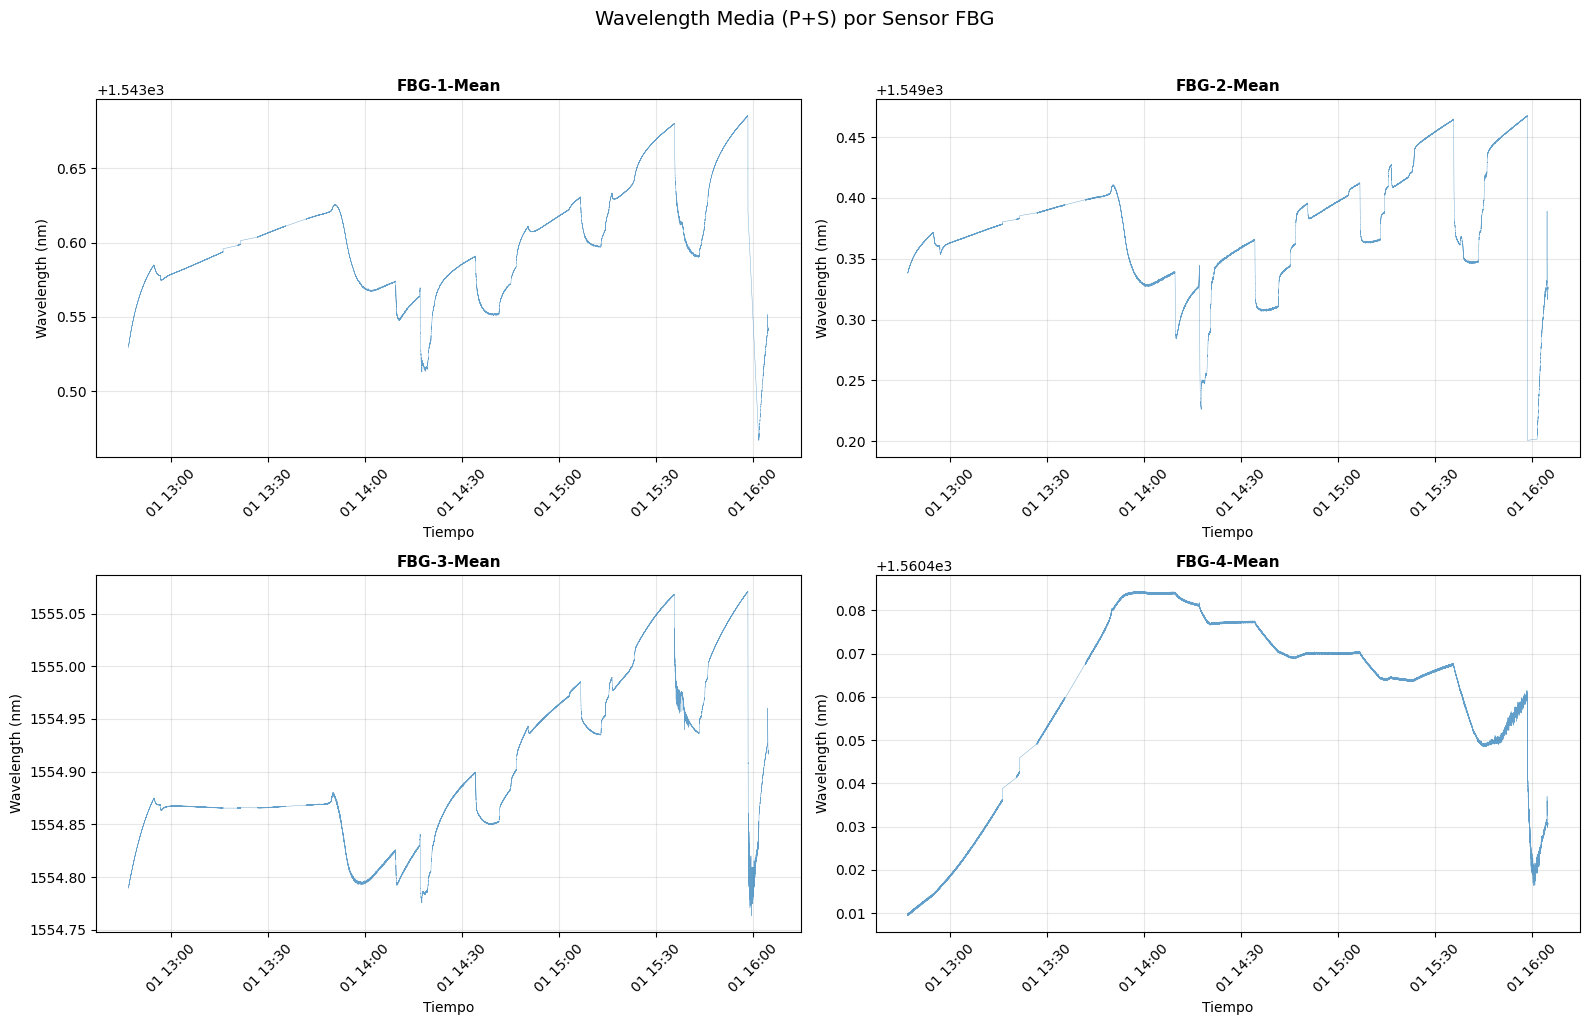

In [10]:
# Ajustar layout para N sensores activos
n_sensors = len(fbg_mean_data)

if n_sensors <= 3:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    
    ax = axes[idx]
    ax.plot(times_fbg, wav_fbg, linewidth=0.3, alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Wavelength (nm)')
    ax.set_xlabel('Tiempo')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Wavelength Media (P+S) por Sensor FBG', fontsize=14, y=1.02)
plt.tight_layout()


## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

En este setup, **solo RTD-7 (índice 7)** está en la cápsula de la fibra.


In [11]:
# Usar RTD-7 (único RTD en cápsula fibra) como referencia
rtd_ref_idx = 5
rtd_ref_name = "RTD-7 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")


✅ Referencia: RTD-7 (Cápsula)
   Rango: [77.58, 92.64] K


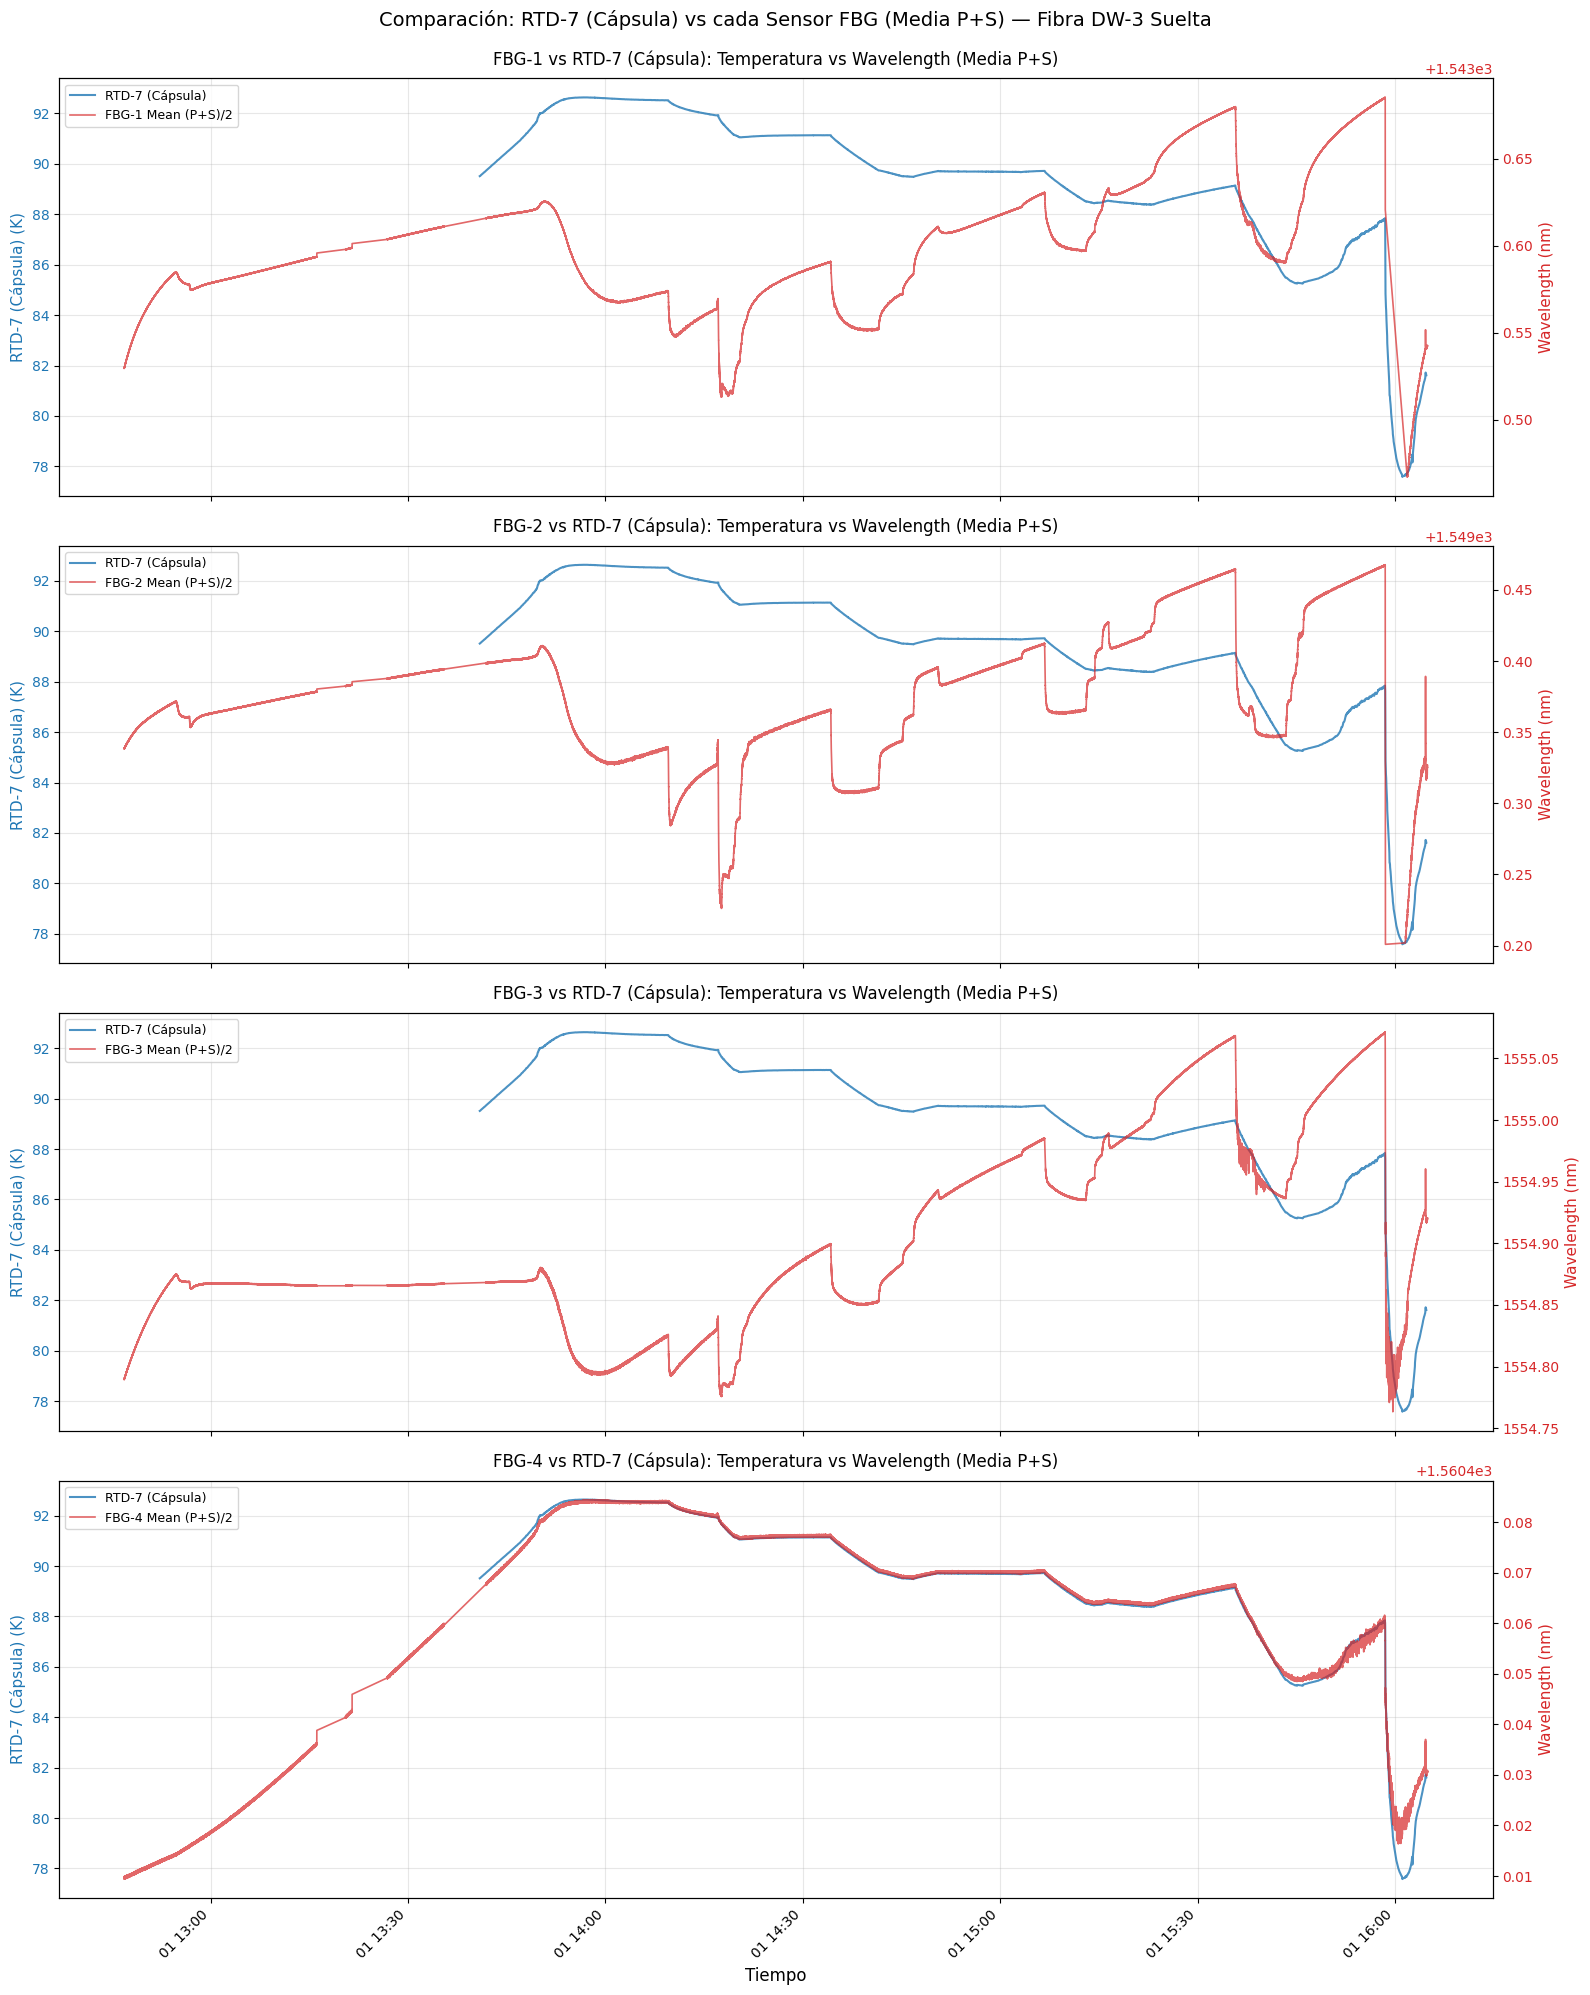


✅ Gráficos superpuestos generados para 4 sensores FBG vs RTD-7 (Cápsula)
   🎯 Objetivo: identificar qué sensor FBG correlaciona mejor con el RTD de la cápsula
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [12]:
# Superposición de temperatura (RTD-7) con cada sensor FBG
# Objetivo: comparar qué sensor FBG correlaciona mejor con el RTD de la cápsula

n_plots = len(fbg_mean_data)
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 5*n_plots), sharex=True)

if n_plots == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, (fbg_label, fbg_data_plot) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data_plot['sensor_num']
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"],
             color=color_wav, linewidth=1.2, alpha=0.7,
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                        Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines,
                   labels1 + labels2 + ['Inicio plateau', 'Fin plateau'],
                   loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num} vs {rtd_ref_name}: Temperatura vs Wavelength (Media P+S)',
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación: {rtd_ref_name} vs cada Sensor FBG (Media P+S) — Fibra DW-3 Suelta',
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n✅ Gráficos superpuestos generados para {n_plots} sensores FBG vs {rtd_ref_name}")
print(f"   🎯 Objetivo: identificar qué sensor FBG correlaciona mejor con el RTD de la cápsula")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

In [13]:
# ======================================================================
# INSPECCIÓN DEL ESPECTRO: ¿Cuántos picos FBG se ven?
# ======================================================================
# En 20260202, la fibra DW-3 tenía 4 canales configurados pero solo 3 funcionales.
# El 5º FBG estaba al límite del rango del interrogador.
# Ahora con la fibra suelta (sin PTFE, sin peso), ¿se ven los mismos picos?

print("="*70)
print("🔍 INSPECCIÓN DEL ESPECTRO FBG")
print("="*70)

# Mostrar rango de wavelength por sensor/canal
n_total_sensors = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
print(f"\n📊 Canales totales en el archivo: {n_total_sensors}")
print(f"   Sensores activos detectados: {active_sensors}")

# Para cada sensor, mostrar estadísticas
for i in range(n_total_sensors):
    sensor_num = i + 1
    print(f"\n--- Sensor FBG-{sensor_num} (índice {i}) ---")
    for pol_idx, pol_name in enumerate(['P', 'S']):
        wav_data = wav_raw[:, pol_idx, i]
        mask_pos = wav_data > 0
        n_valid = mask_pos.sum()
        if n_valid > 0:
            print(f"   {pol_name}: {n_valid} puntos válidos, "
                  f"rango [{wav_data[mask_pos].min():.3f}, {wav_data[mask_pos].max():.3f}] nm, "
                  f"media={wav_data[mask_pos].mean():.3f} nm")
        else:
            print(f"   {pol_name}: ❌ SIN DATOS VÁLIDOS")

print(f"\n📌 CONCLUSIÓN:")
if len(active_sensors) == n_total_sensors:
    print(f"   ✅ Todos los {n_total_sensors} sensores tienen datos válidos.")
    if n_total_sensors >= 5:
        print(f"   → Se ven los 5 picos esperados en el espectro.")
    elif n_total_sensors == 4:
        print(f"   → Se ven 4 picos. El 5º FBG sigue sin ser visible.")
    else:
        print(f"   → Se ven solo {n_total_sensors} picos.")
else:
    omitted = [i+1 for i in range(n_total_sensors) if (i+1) not in active_sensors]
    print(f"   ⚠️  Solo {len(active_sensors)} de {n_total_sensors} sensores son funcionales.")
    print(f"   Sensores sin datos: {omitted}")


🔍 INSPECCIÓN DEL ESPECTRO FBG

📊 Canales totales en el archivo: 5
   Sensores activos detectados: [1, 2, 3, 4]

--- Sensor FBG-1 (índice 0) ---
   P: 1359060 puntos válidos, rango [1543.344, 1543.681] nm, media=1543.596 nm
   S: 1360660 puntos válidos, rango [1543.353, 1543.690] nm, media=1543.597 nm

--- Sensor FBG-2 (índice 1) ---
   P: 1365249 puntos válidos, rango [1549.034, 1549.467] nm, media=1549.369 nm
   S: 1365250 puntos válidos, rango [1549.044, 1549.469] nm, media=1549.373 nm

--- Sensor FBG-3 (índice 2) ---
   P: 1364022 puntos válidos, rango [1554.764, 1555.071] nm, media=1554.903 nm
   S: 1365250 puntos válidos, rango [1554.762, 1555.072] nm, media=1554.906 nm

--- Sensor FBG-4 (índice 3) ---
   P: 1365249 puntos válidos, rango [1560.410, 1560.485] nm, media=1560.457 nm
   S: 1365250 puntos válidos, rango [1560.409, 1560.486] nm, media=1560.463 nm

--- Sensor FBG-5 (índice 4) ---
   P: ❌ SIN DATOS VÁLIDOS
   S: ❌ SIN DATOS VÁLIDOS

📌 CONCLUSIÓN:
   ⚠️  Solo 4 de 5 sensor

### 6.2 Visualización de Perfiles (para definir plateaus)



### 6.3 Definición Manual de Plateaus



In [14]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en los gráficos de la sección 6.2)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

#manual_plateaus = [
    #("Plateau 1", "16:56", "17:01"),
    #("Plateau 2", "17:06", "17:12"),
    #("Plateau 3", "17:17", "17:21"),
    #("Plateau 4", "17:26", "17:30"),
    #("Plateau 5", "17:40", "17:50"),
#]

manual_plateaus = [
    ("Plateau 1", "13:55", "14:05"),  # 4 min (recortado el inicio)
    ("Plateau 2", "14:25", "14:32"),  # 4 min (recortado el inicio)
    ("Plateau 3", "14:55", "15:05"),  # 4 min (se queda igual)
]

# Fecha del ensayo (para construir datetime de los plateaus)
fecha = datetime.date(2026, 7, 1)

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*70)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "n_temp_points": len(temp_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*70)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1: 13:55 - 14:05
  Temperatura: μ=92.599K, σ=0.0312K, n=341
Plateau 2: 14:25 - 14:32
  Temperatura: μ=91.130K, σ=0.0054K, n=239
Plateau 3: 14:55 - 15:05
  Temperatura: μ=89.691K, σ=0.0065K, n=338

✅ 3 plateaus definidos


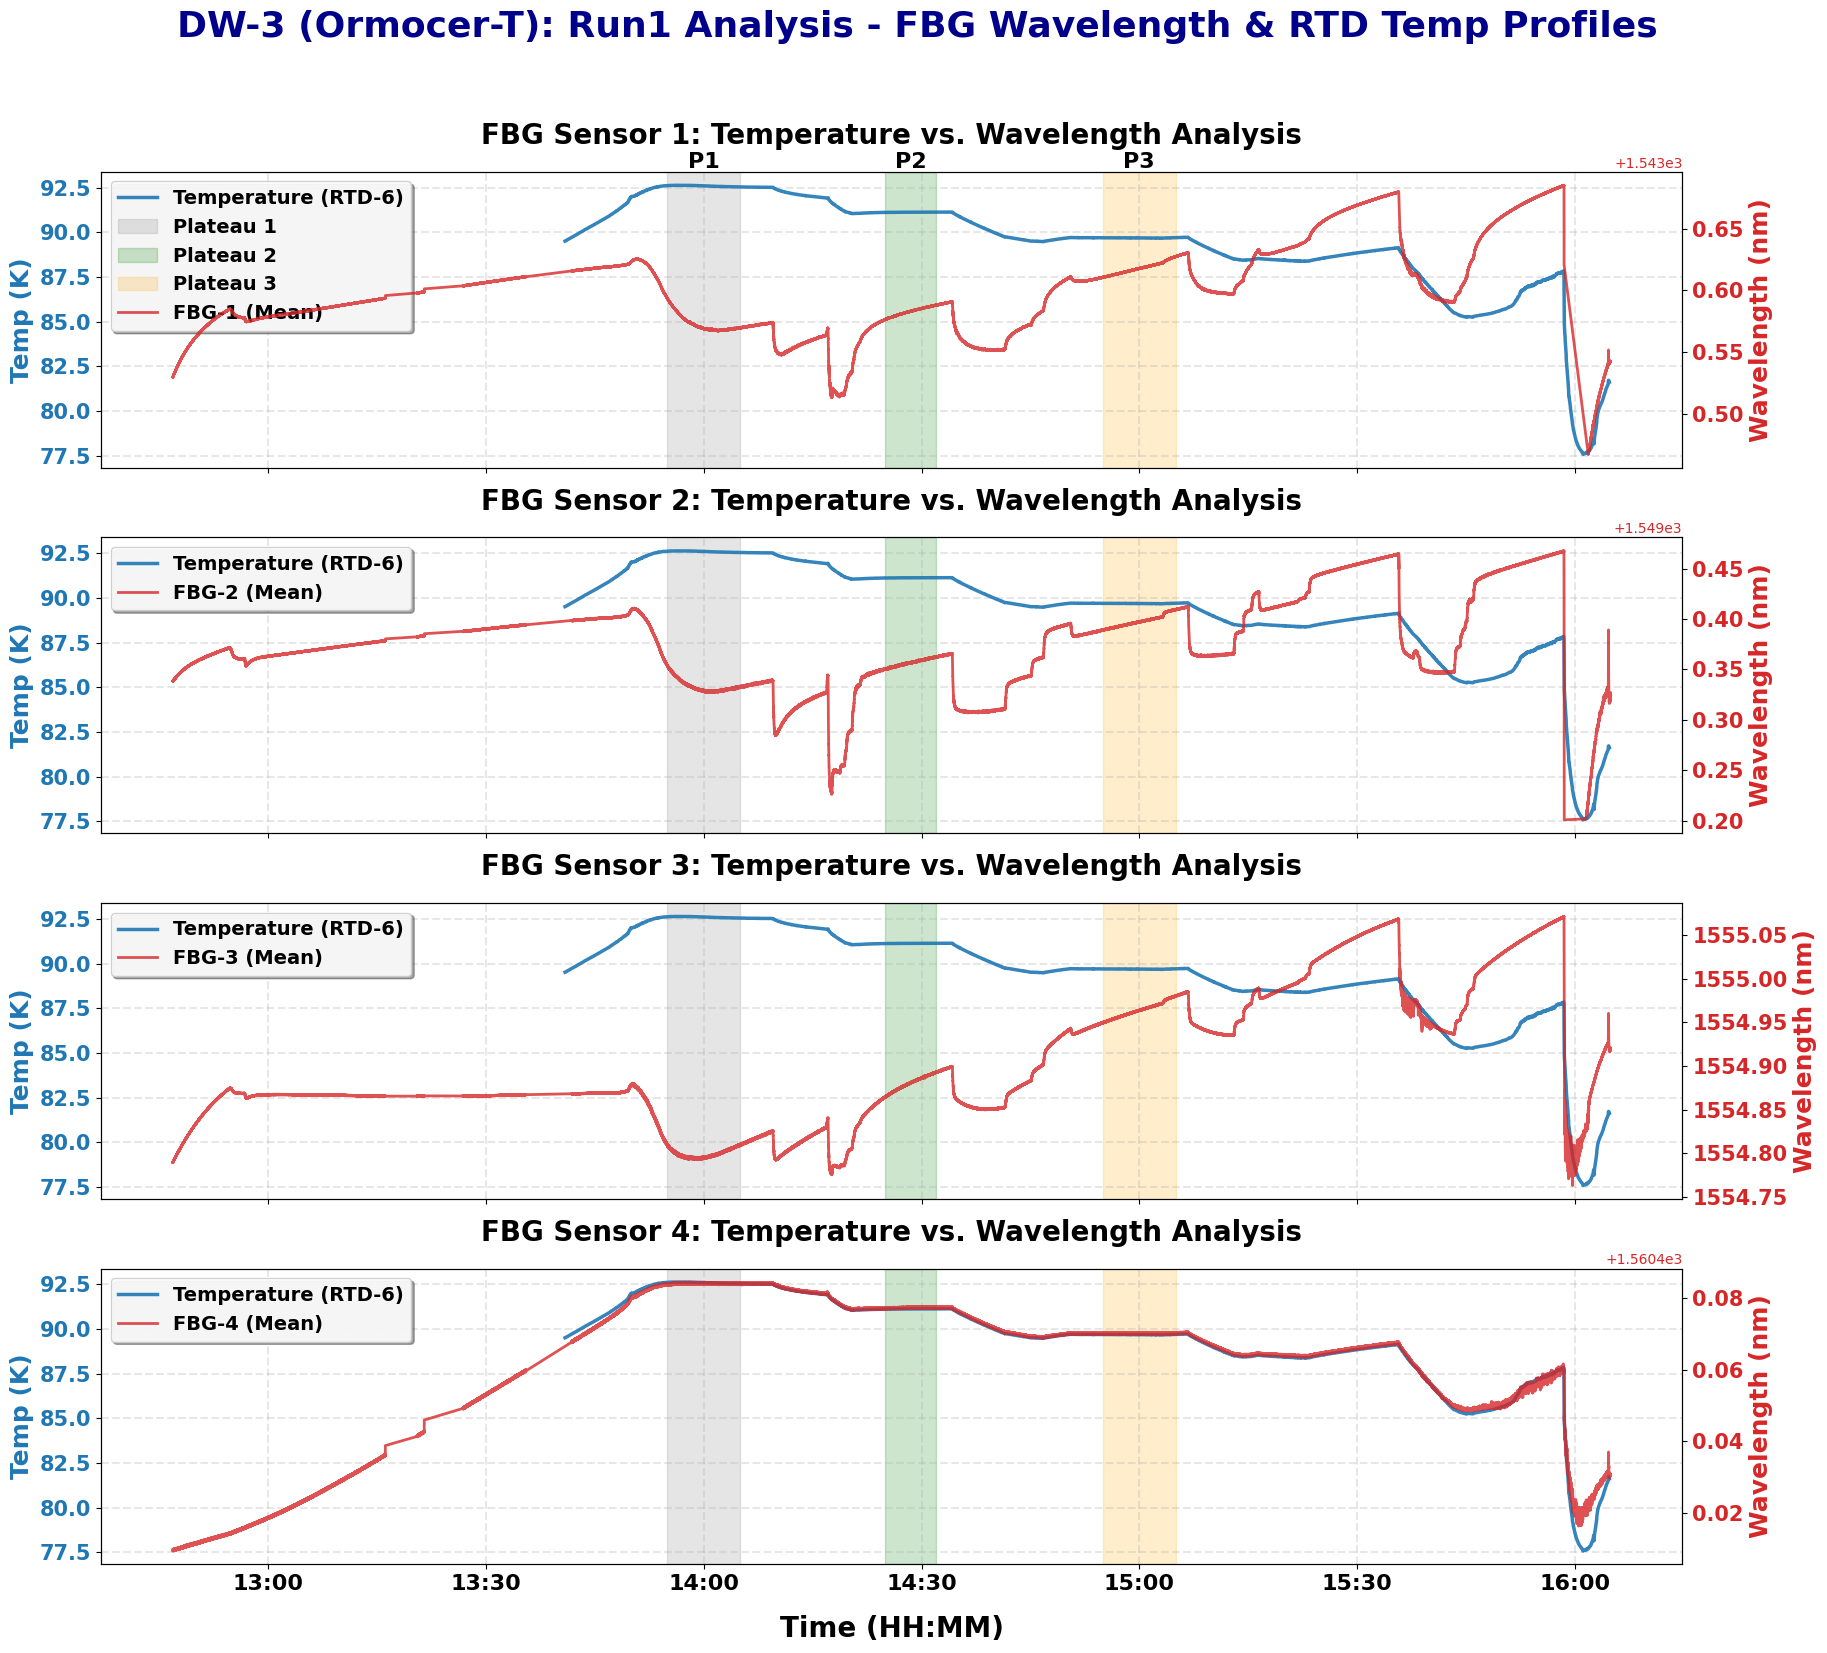

In [15]:
# ============================================================================
# PLOT: Wavelength vs Temperature with Shaded Plateaus (SLIDE OPTIMIZED)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav = 'tab:red'
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

# Aumentamos el tamaño de la figura para que tenga más resolución
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3, 4]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
        
    fbg_data_plot = fbg_mean_data[fbg_label]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature
    # Aumentamos fontsize a 18 y ponemos negrita extra
    ax1.set_ylabel(f'Temp (K)', fontsize=18, color=color_temp, fontweight='black')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=2.5, alpha=0.9, label='Temperature (RTD-6)')
    
    # Ticks más grandes y en negrita
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=15)
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
        
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.2, 
                        label=f'Plateau {p_idx+1}' if idx == 0 else "")
            
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                # Etiquetas de plateau más grandes (P1, P2...)
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=16, color='black', fontweight='bold')

    # 3. Right Axis: Wavelength
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=18, color=color_wav, fontweight='black')
    # Línea de wavelength más gruesa para visibilidad
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=2.0, alpha=0.8, 
             label=f'FBG-{sensor_num} (Mean)')
    
    ax2.tick_params(axis='y', labelcolor=color_wav, labelsize=15)
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    # Titles de cada subplot más grandes
    ax1.set_title(f'FBG Sensor {sensor_num}: Temperature vs. Wavelength Analysis', 
                  fontsize=20, pad=20, fontweight='bold', color='black')
    
    # Leyendas más legibles y con sombra para destacar
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                     frameon=True, framealpha=0.9, fontsize=14, shadow=True)
    plt.setp(leg.get_texts(), fontweight='bold')

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM)', fontsize=20, fontweight='black', labelpad=15)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Ticks del eje X más grandes
for label in axes[-1].get_xticklabels():
    label.set_rotation(0) # He puesto 0 en vez de 45 para que sea más fácil de leer en slide
    label.set_ha('center')
    label.set_fontsize(16)
    label.set_fontweight('bold')

# Título Global GIGANTE para la slide
plt.suptitle('DW-3 (Ormocer-T): Run1 Analysis - FBG Wavelength & RTD Temp Profiles', 
             fontsize=26, y=1.03, fontweight='black', color='darkblue')

plt.tight_layout()
plt.show()



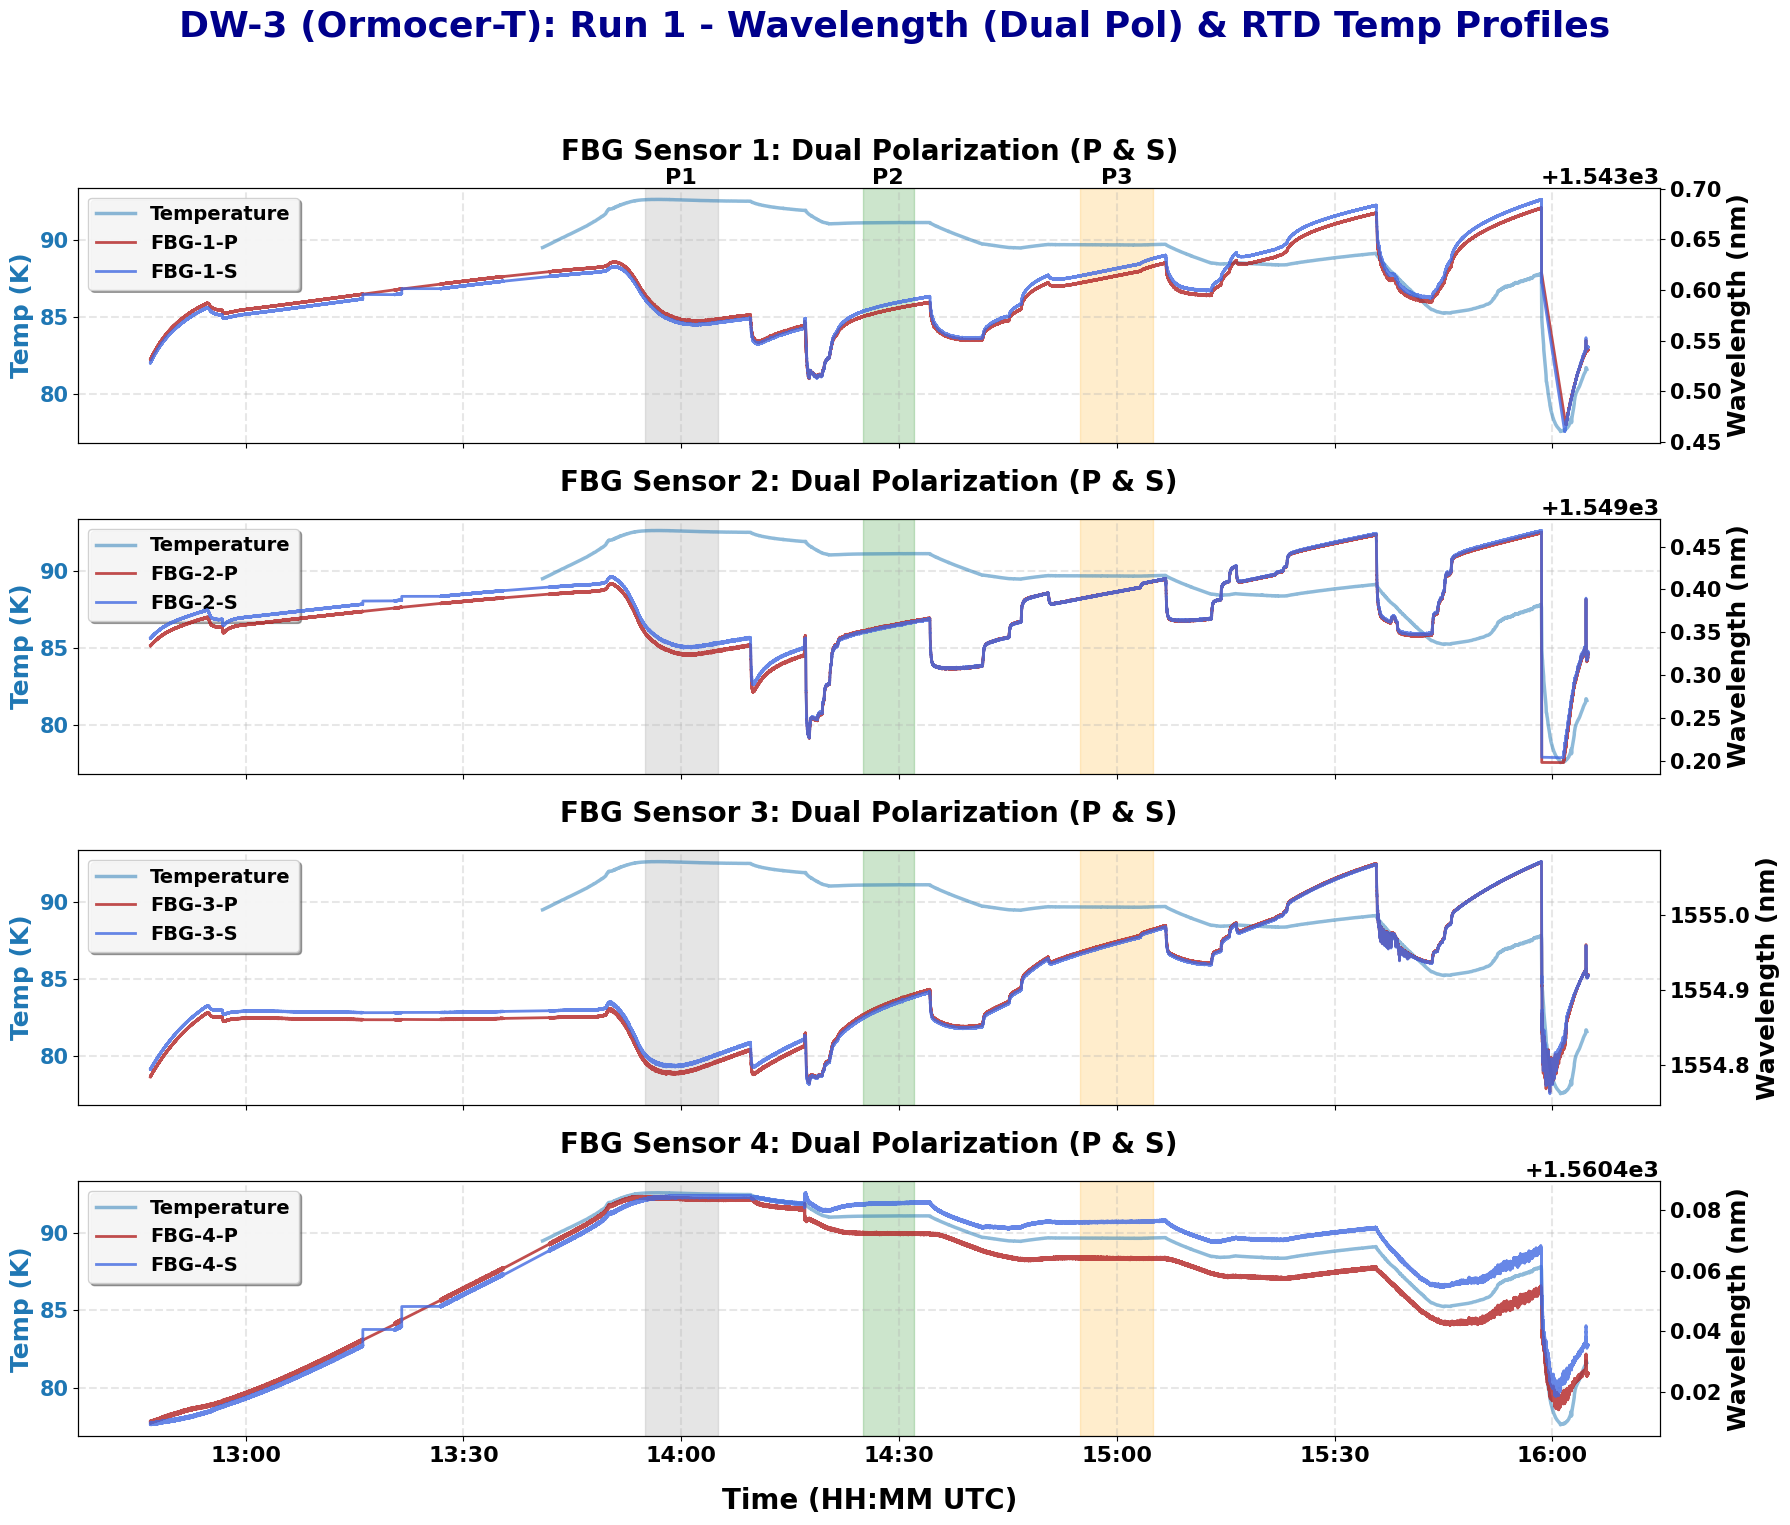

In [16]:
# ============================================================================
# PLOT: Dual Polarization (P & S) vs Temp (SLIDE OPTIMIZED & FIXED AXIS OFFSET)
# Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-07-01
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   
color_pol_s = 'royalblue'   
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3, 4]):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data or label_s not in fbg_filtered_data:
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature
    ax1.set_ylabel(f'Temp (K)', fontsize=18, color=color_temp, fontweight='black')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=2.5, alpha=0.5, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=15)
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.2)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')

    # 3. Right Axis: Wavelength (P & S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=18, color='black', fontweight='black')
    
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_pol_p, linewidth=2.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_pol_s, linewidth=2.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    
    ax2.tick_params(axis='y', labelcolor='black', labelsize=15)
    
    # --- FIX: AJUSTE DEL FACTOR COMÚN (OFFSET/SCIENTIFIC NOTATION) ---
    # Esto asegura que el "1.55" o el "+1e3" se vea grande y en negrita
    y_formatter = ax2.yaxis.get_major_formatter()
    ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
    ax2.yaxis.get_offset_text().set_fontsize(16)
    ax2.yaxis.get_offset_text().set_fontweight('bold')
    
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    # Estilo de Subplots
    ax1.set_title(f'FBG Sensor {sensor_num}: Dual Polarization (P & S)', 
                  fontsize=20, pad=20, fontweight='bold')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                     frameon=True, framealpha=0.9, fontsize=14, shadow=True)
    plt.setp(leg.get_texts(), fontweight='bold')

# Format X-Axis
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=20, fontweight='black', labelpad=15)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_fontsize(16)
    label.set_fontweight('bold')

# Global Title
plt.suptitle('DW-3 (Ormocer-T): Run 1 - Wavelength (Dual Pol) & RTD Temp Profiles', 
             fontsize=26, y=0.98, fontweight='black', color='darkblue')

plt.tight_layout(rect=[0, 0.03, 1, 0.94])


### 6.4 Calcular Sensibilidad por Plateaus



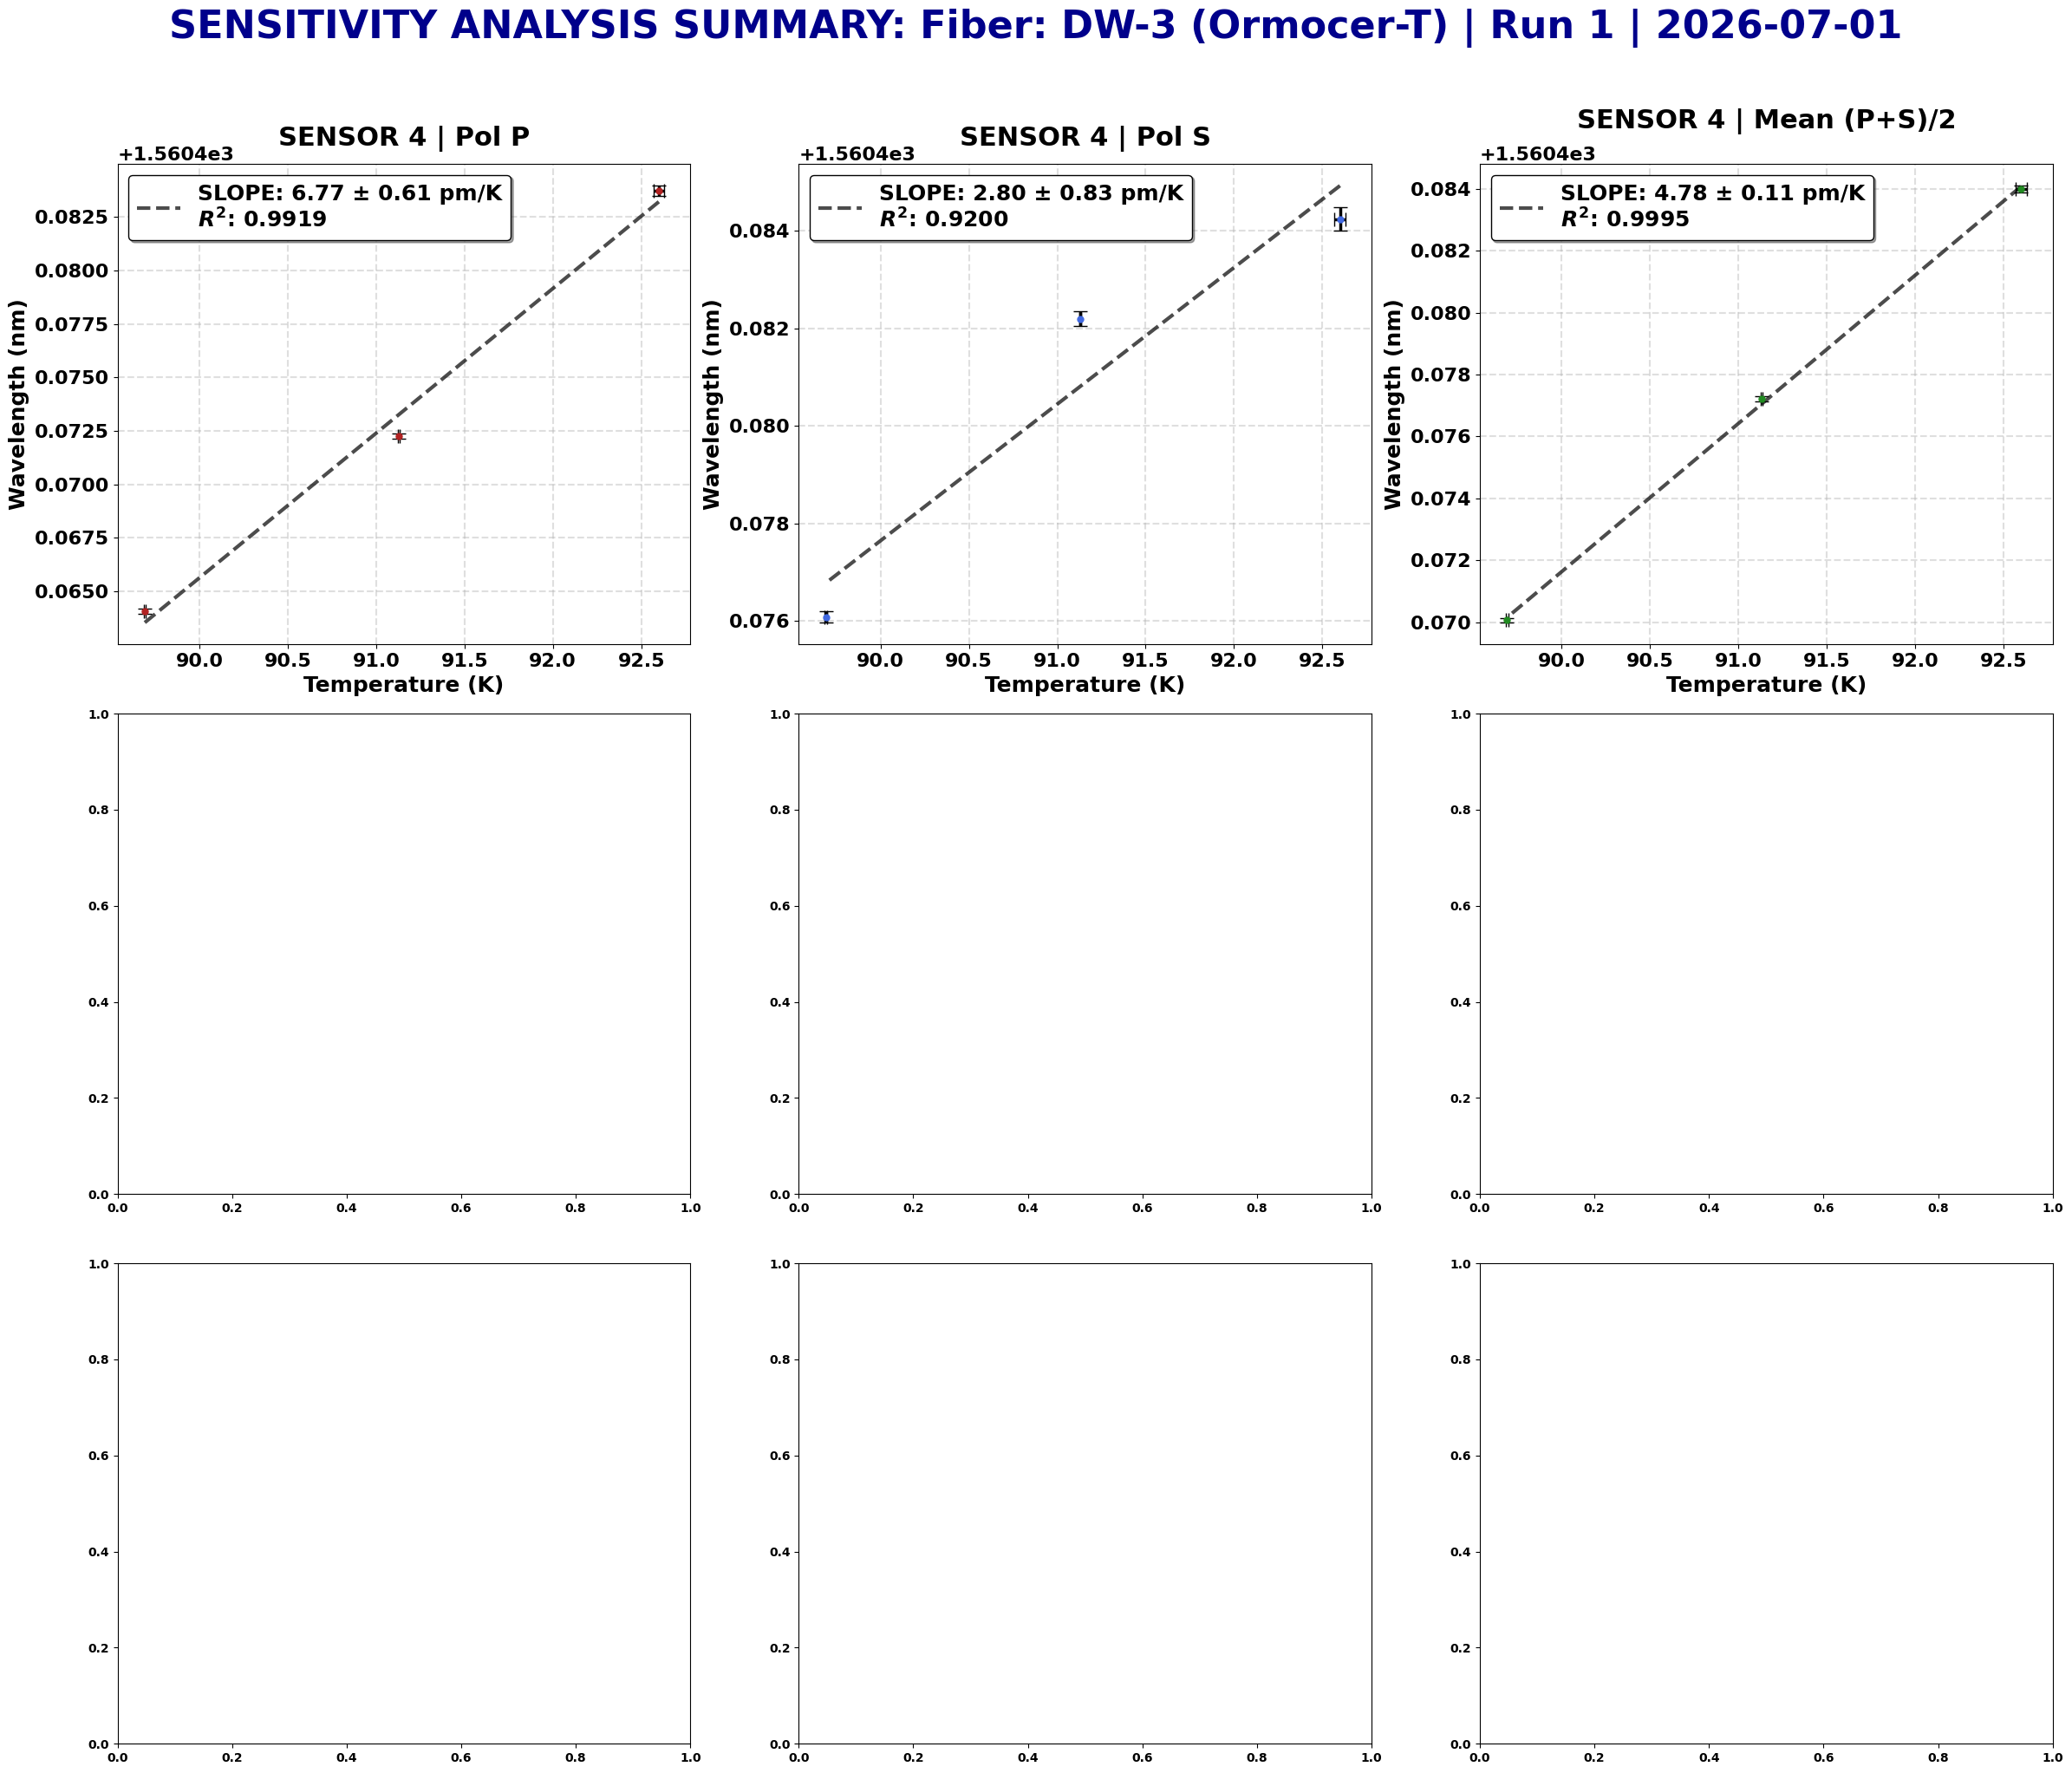


                         SENSITIVITY SUMMARY TABLE: FIBER DW-3 (Run 1)                         
Sensor   | Type            | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
S4       | Pol P           |        6.766       |        0.611    | 0.9919
S4       | Pol S           |        2.801       |        0.826    | 0.9200
S4       | Mean (P+S)/2    |        4.784       |        0.107    | 0.9995


In [18]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Estructura para guardar resultados
summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-07-01"

# --- CREAMOS UNA SOLA FIGURA (3 Sensores x 3 Tipos = 9 Subplots o 3x3) ---
# He optado por una matriz 3x3 para que cada sensor tenga su fila
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([4]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"])
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    if len(wav_data) > 0:
                        w_means.append(np.mean(wav_data)); w_stds.append(np.std(wav_data))
                    else:
                        w_means.append(np.nan); w_stds.append(np.nan)

            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                slope_pm, err_pm = slope * 1e3, std_err * 1e3
                
                summary_results.append({
                    "Sensor": f"S{sensor_num}", "Type": config["title"],
                    "Slope": slope_pm, "Error": err_pm, "R2": r_val**2
                })

                # --- PLOT DE ALTA VISIBILIDAD ---
                # Puntos y barras de error más gruesas
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=2.5, capsize=6, markersize=5,
                            label='Experimental Data')
                
                # Línea de ajuste más marcada
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', linewidth=3, alpha=0.7)

                # --- LEYENDA GIGANTE CON LA SLOPE ---
                slope_label = f"SLOPE: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
                leg = ax.legend([slope_label], loc='upper left', fontsize=18, 
                                 frameon=True, shadow=True, facecolor='white', edgecolor='black')
                plt.setp(leg.get_texts(), fontweight='black')

                # Estilo de ejes (Grande y Negrita)
                ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
                ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
                ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')
                
                # Números de los ejes grandes
                ax.tick_params(axis='both', which='major', labelsize=16)
                for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                    label_tick.set_fontweight('bold')

                # Factor común (Offset) grande
                ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
                ax.yaxis.get_offset_text().set_fontsize(16)
                ax.yaxis.get_offset_text().set_fontweight('bold')
                
                ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

# Título Global para la Slide
plt.suptitle(f"SENSITIVITY ANALYSIS SUMMARY: {fiber_info}", 
             fontsize=32, y=1.02, fontweight='black', color='darkblue')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY TABLE (IMPRESIÓN EN CONSOLA)
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER DW-3 (Run 1)':^95}")
print("="*95)
print(f"{'Sensor':<8} | {'Type':<15} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<8} | {res['Type']:<15} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")


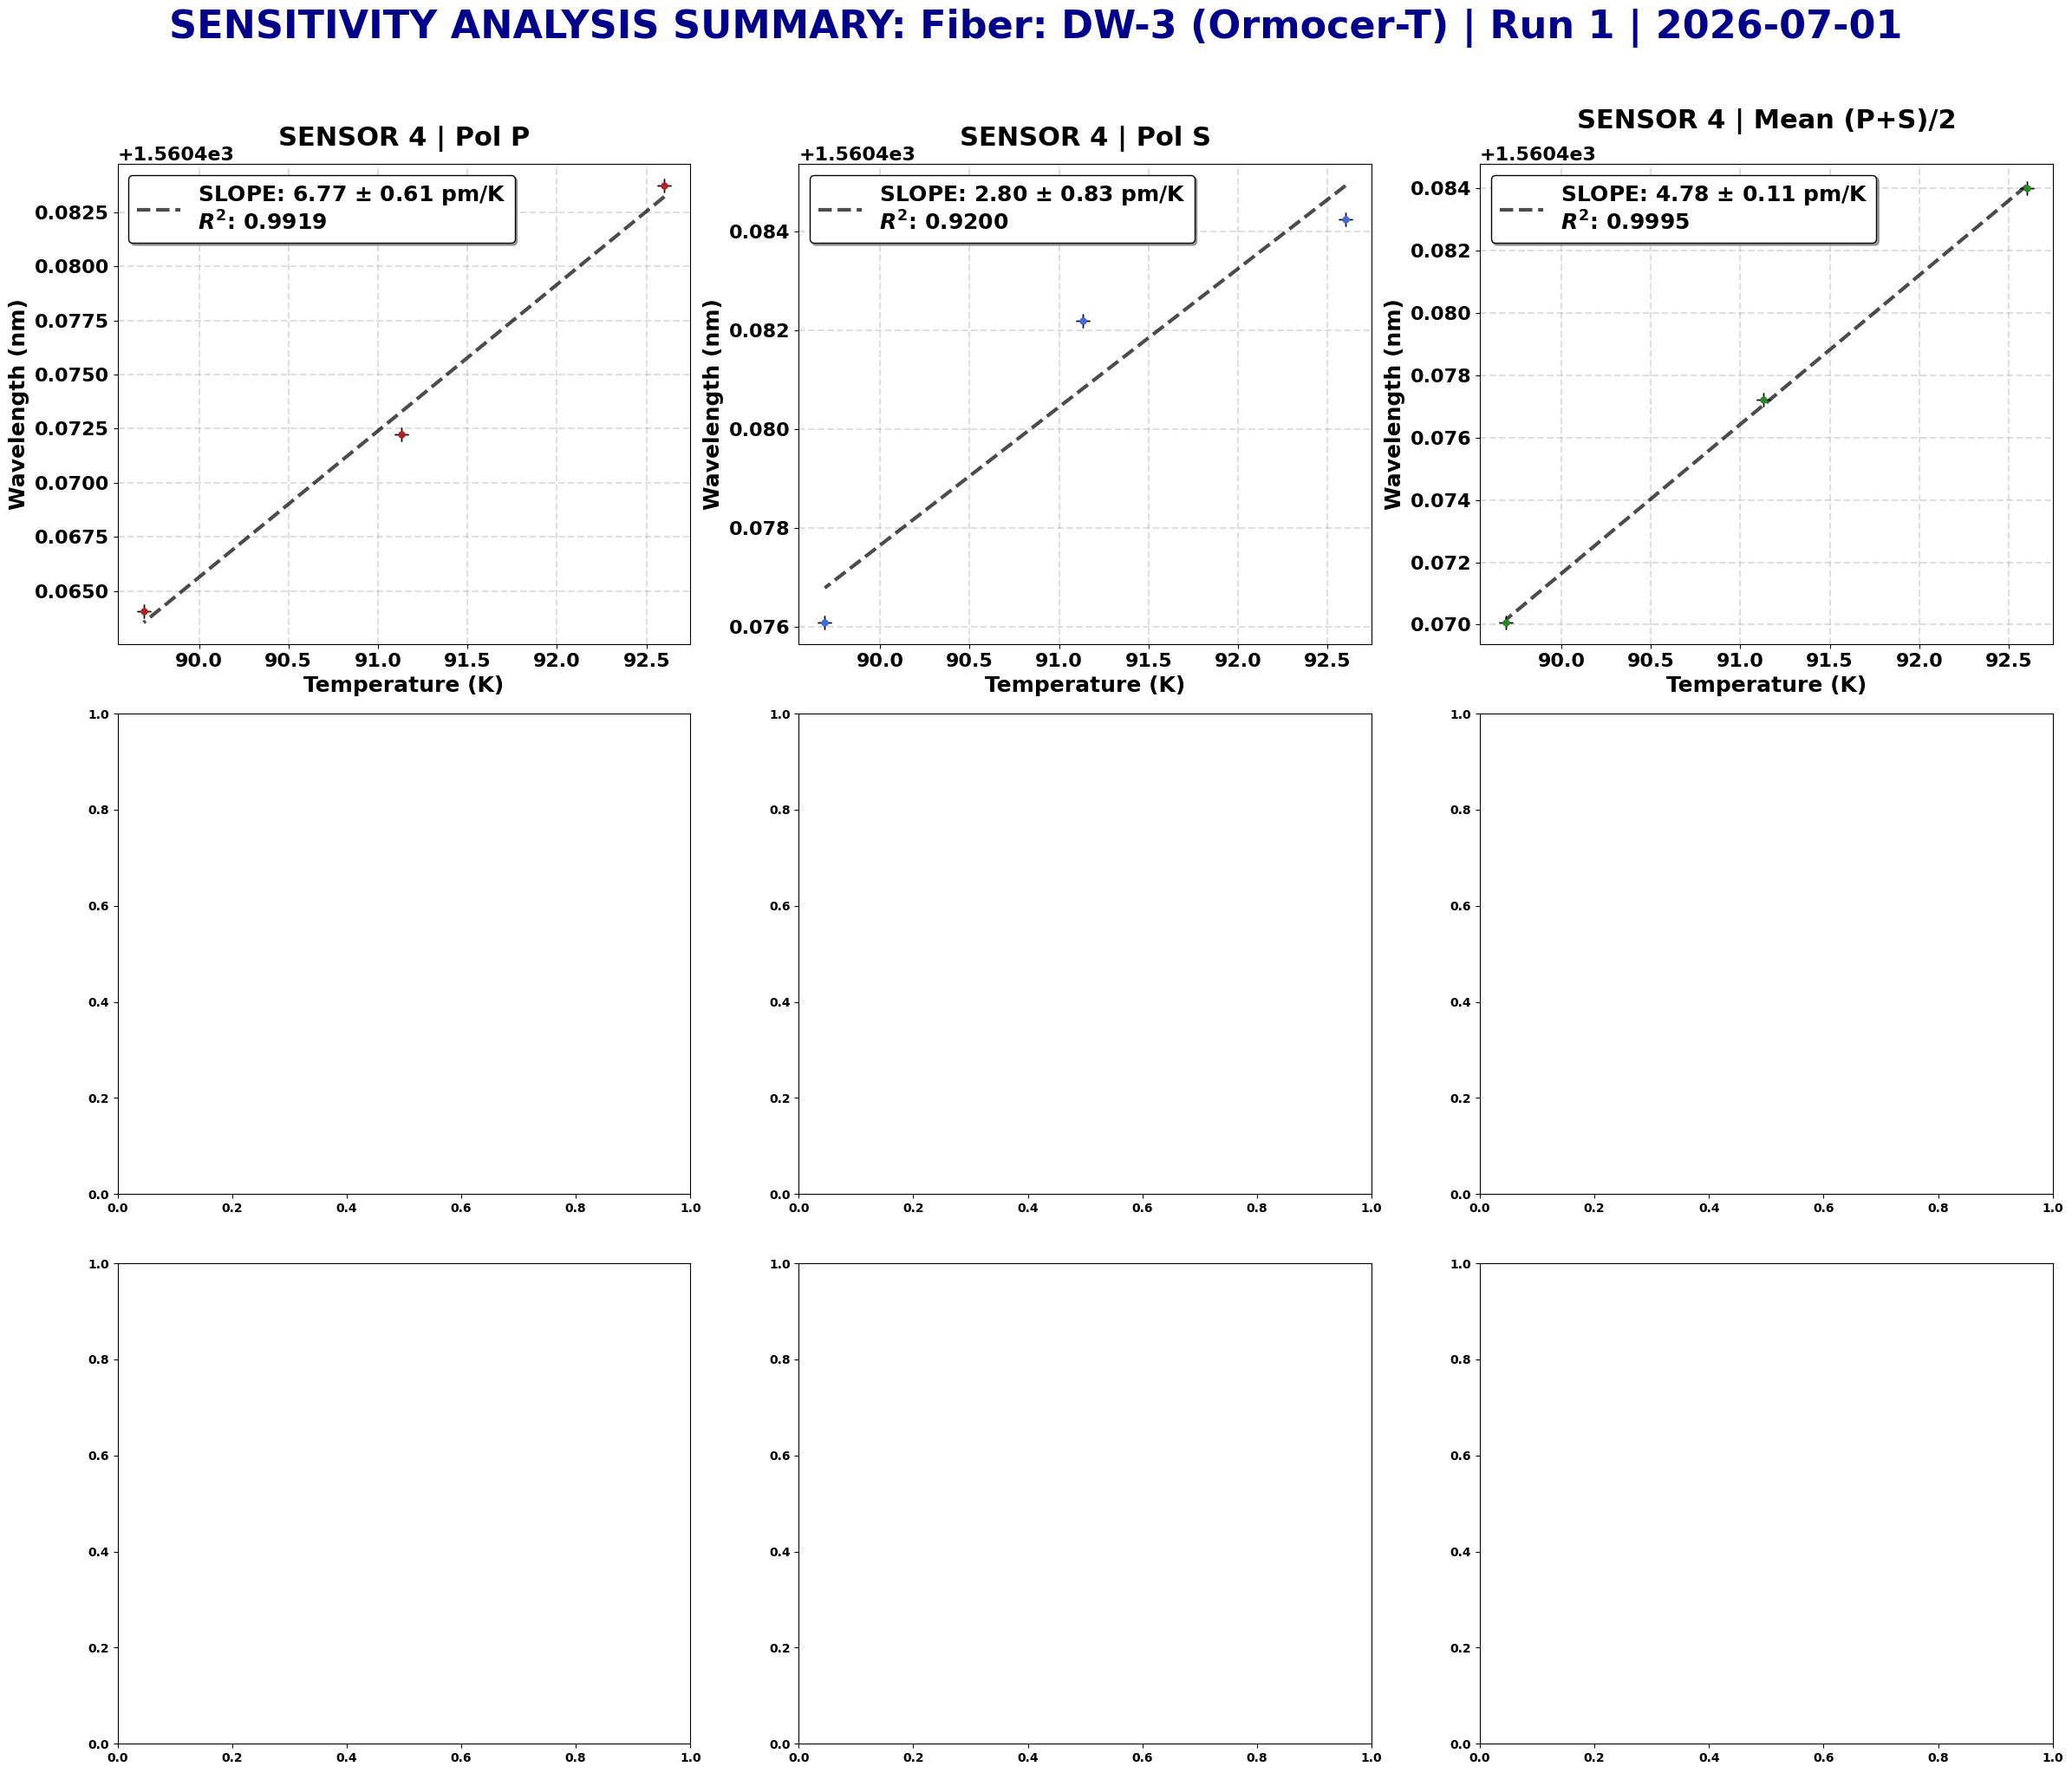

In [19]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-07-01"

fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([4]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        # Aquí guardaremos las medias y sus correspondientes SEM (Error de la media)
        t_means, t_sems, w_means, w_sems = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    
                    if len(wav_data) > 0:
                        # Número de muestras en este plateau
                        n_samples = len(wav_data)
                        
                        # Guardamos las medias de X e Y
                        t_means.append(p["temp_mean"])
                        w_means.append(np.mean(wav_data))
                        
                        # --- NUEVO: CÁLCULO DEL ERROR DE LA MEDIA (SEM) ---
                        # Para longitud de onda usamos stats.sem de Scipy
                        w_sems.append(stats.sem(wav_data))
                        
                        # Para temperatura, calculamos el SEM usando la desviación estándar y la raíz de N
                        # (Asumiendo que el sensor de temperatura y el FBG miden en ventanas temporales equivalentes)
                        t_sems.append(p["temp_std"] / np.sqrt(n_samples))
                    else:
                        w_means.append(np.nan); w_sems.append(np.nan)
                        t_means.append(np.nan); t_sems.append(np.nan)

            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_sems); y_err = np.array(w_sems)  # <--- Ahora usamos los SEM
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                slope_pm, err_pm = slope * 1e3, std_err * 1e3
                
                summary_results.append({
                    "Sensor": f"S{sensor_num}", "Type": config["title"],
                    "Slope": slope_pm, "Error": err_pm, "R2": r_val**2
                })

                # --- PLOT DE ALTA VISIBILIDAD (Con barras de error SEM) ---
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=2.5, capsize=6, markersize=5,
                            label='Experimental Data')
                
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', linewidth=3, alpha=0.7)

                # --- LEYENDA GIGANTE CON LA SLOPE ---
                slope_label = f"SLOPE: {slope_pm:.2f} $\pm$ {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
                leg = ax.legend([slope_label], loc='upper left', fontsize=18, 
                                 frameon=True, shadow=True, facecolor='white', edgecolor='black')
                plt.setp(leg.get_texts(), fontweight='black')

                ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
                ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
                ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')
                
                ax.tick_params(axis='both', which='major', labelsize=16)
                for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                    label_tick.set_fontweight('bold')

                ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
                ax.yaxis.get_offset_text().set_fontsize(16)
                ax.yaxis.get_offset_text().set_fontweight('bold')
                
                ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

plt.suptitle(f"SENSITIVITY ANALYSIS SUMMARY: {fiber_info}", 
             fontsize=32, y=1.02, fontweight='black', color='darkblue')

plt.tight_layout()


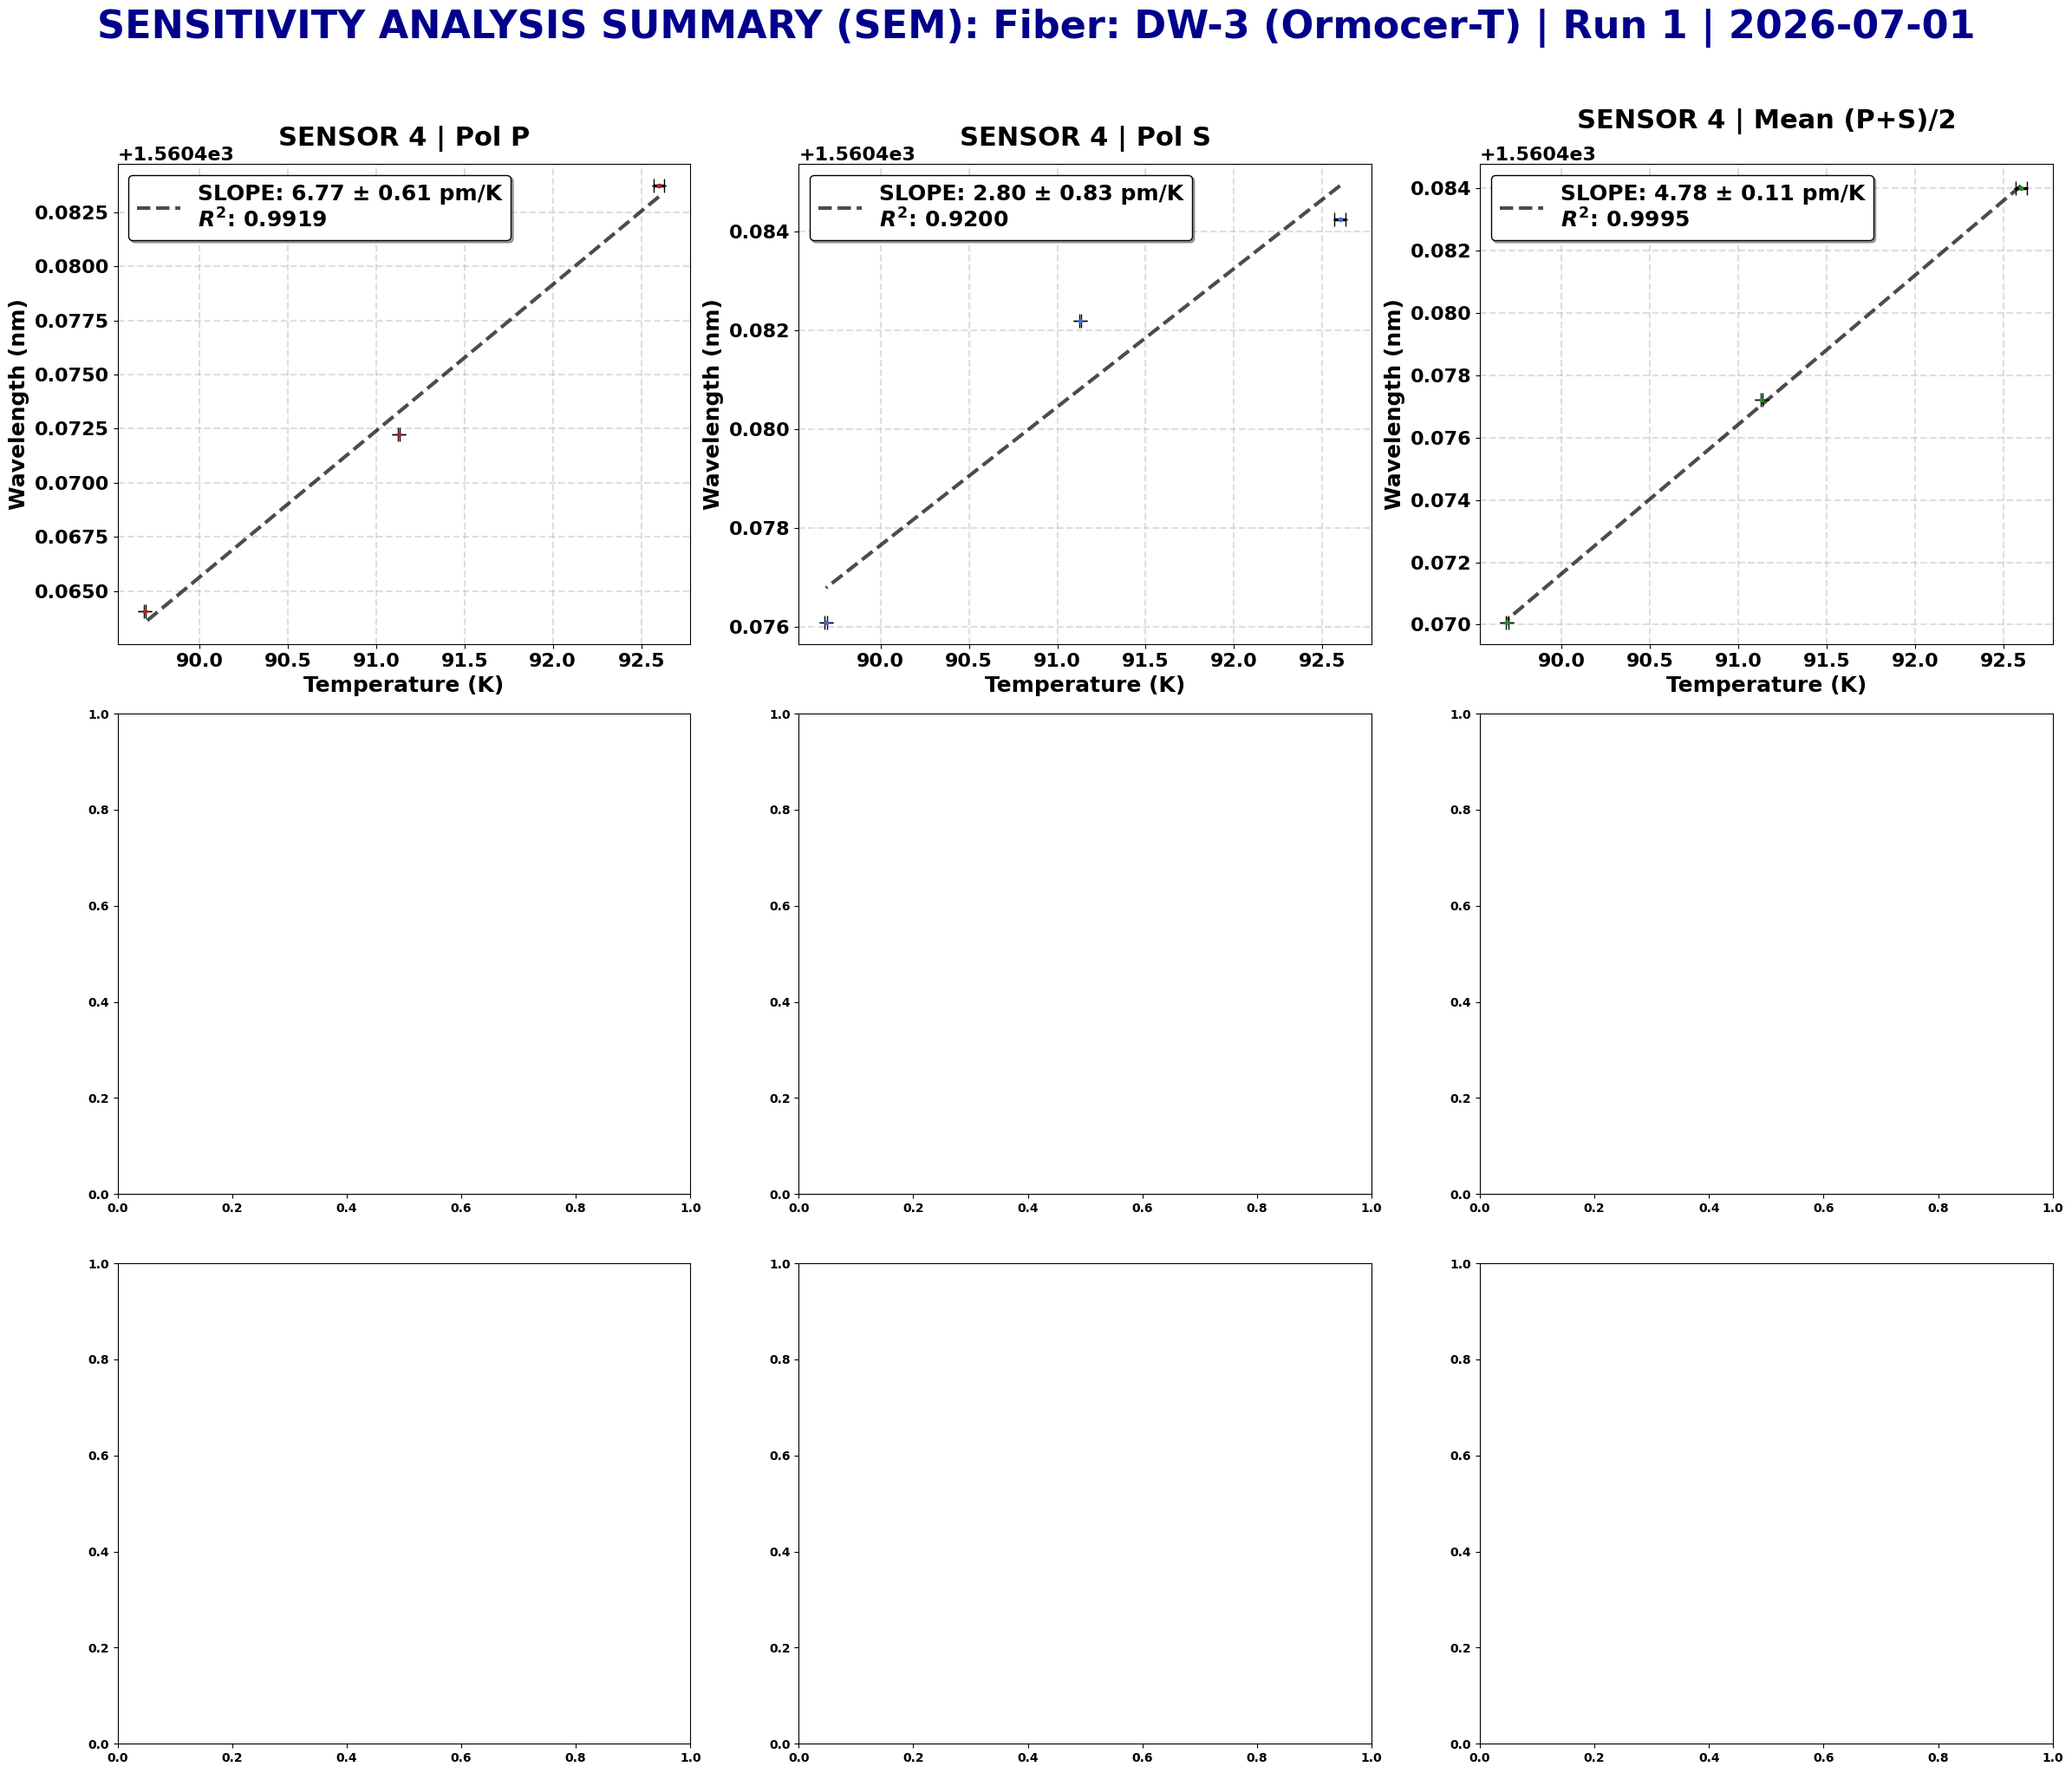


                      SENSITIVITY SUMMARY TABLE (SEM): FIBER DW-3 (Run 1)                      
Sensor   | Type            | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
S4       | Pol P           |        6.766       |        0.611    | 0.9919
S4       | Pol S           |        2.801       |        0.826    | 0.9200
S4       | Mean (P+S)/2    |        4.784       |        0.107    | 0.9995


In [20]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS (SEM): Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Estructura para guardar resultados
summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-07-01"

# --- CREAMOS UNA SOLA FIGURA (3 Sensores x 3 Tipos = 9 Subplots o 3x3) ---
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([4]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        t_means, t_sems, w_means, w_sems = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]

                    if len(wav_data) > 1:
                        # --- Temperature SEM ---
                        t_mean = p["temp_mean"]
                        t_sem = p["temp_std"] / np.sqrt(max(1, p.get("N_temp", 1)))

                        # --- Wavelength SEM ---
                        w_mean = np.mean(wav_data)
                        w_sem = np.std(wav_data, ddof=1) / np.sqrt(len(wav_data))

                        t_means.append(t_mean)
                        t_sems.append(t_sem)
                        w_means.append(w_mean)
                        w_sems.append(w_sem)

        x = np.array(t_means)
        y = np.array(w_means)
        x_err = np.array(t_sems)
        y_err = np.array(w_sems)

        mask_valid = ~np.isnan(x) & ~np.isnan(y)
        x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

        if len(x) > 1:
            slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
            slope_pm, err_pm = slope * 1e3, std_err * 1e3
            
            summary_results.append({
                "Sensor": f"S{sensor_num}",
                "Type": config["title"],
                "Slope": slope_pm,
                "Error": err_pm,
                "R2": r_val**2
            })

            # --- PLOT DE ALTA VISIBILIDAD (SEM) ---
            ax.errorbar(
                x, y,
                xerr=x_err,
                yerr=y_err,
                fmt='o',
                color=config["color"],
                ecolor='black',
                elinewidth=2.5,
                capsize=6,
                markersize=3,   # reducido para visibilidad de barras
                label='Experimental Data'
            )

            # Fit line
            ax.plot(
                x,
                slope*x + intercept,
                color='black',
                linestyle='--',
                linewidth=3,
                alpha=0.7
            )

            # Legend with slope
            slope_label = f"SLOPE: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
            leg = ax.legend(
                [slope_label],
                loc='upper left',
                fontsize=18,
                frameon=True,
                shadow=True,
                facecolor='white',
                edgecolor='black'
            )
            plt.setp(leg.get_texts(), fontweight='black')

            # Titles and labels (NO mention of SEM here except global title)
            ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
            ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
            ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')

            ax.tick_params(axis='both', which='major', labelsize=16)
            for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                label_tick.set_fontweight('bold')

            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
            ax.yaxis.get_offset_text().set_fontsize(16)
            ax.yaxis.get_offset_text().set_fontweight('bold')

            ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

# Global title ONLY mentions SEM
plt.suptitle(
    f"SENSITIVITY ANALYSIS SUMMARY (SEM): {fiber_info}",
    fontsize=32,
    y=1.02,
    fontweight='black',
    color='darkblue'
)

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY TABLE (IMPRESIÓN EN CONSOLA)
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE (SEM): FIBER DW-3 (Run 1)':^95}")
print("="*95)
print(f"{'Sensor':<8} | {'Type':<15} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)

for res in summary_results:
    print(f"{res['Sensor']:<8} | {res['Type']:<15} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")



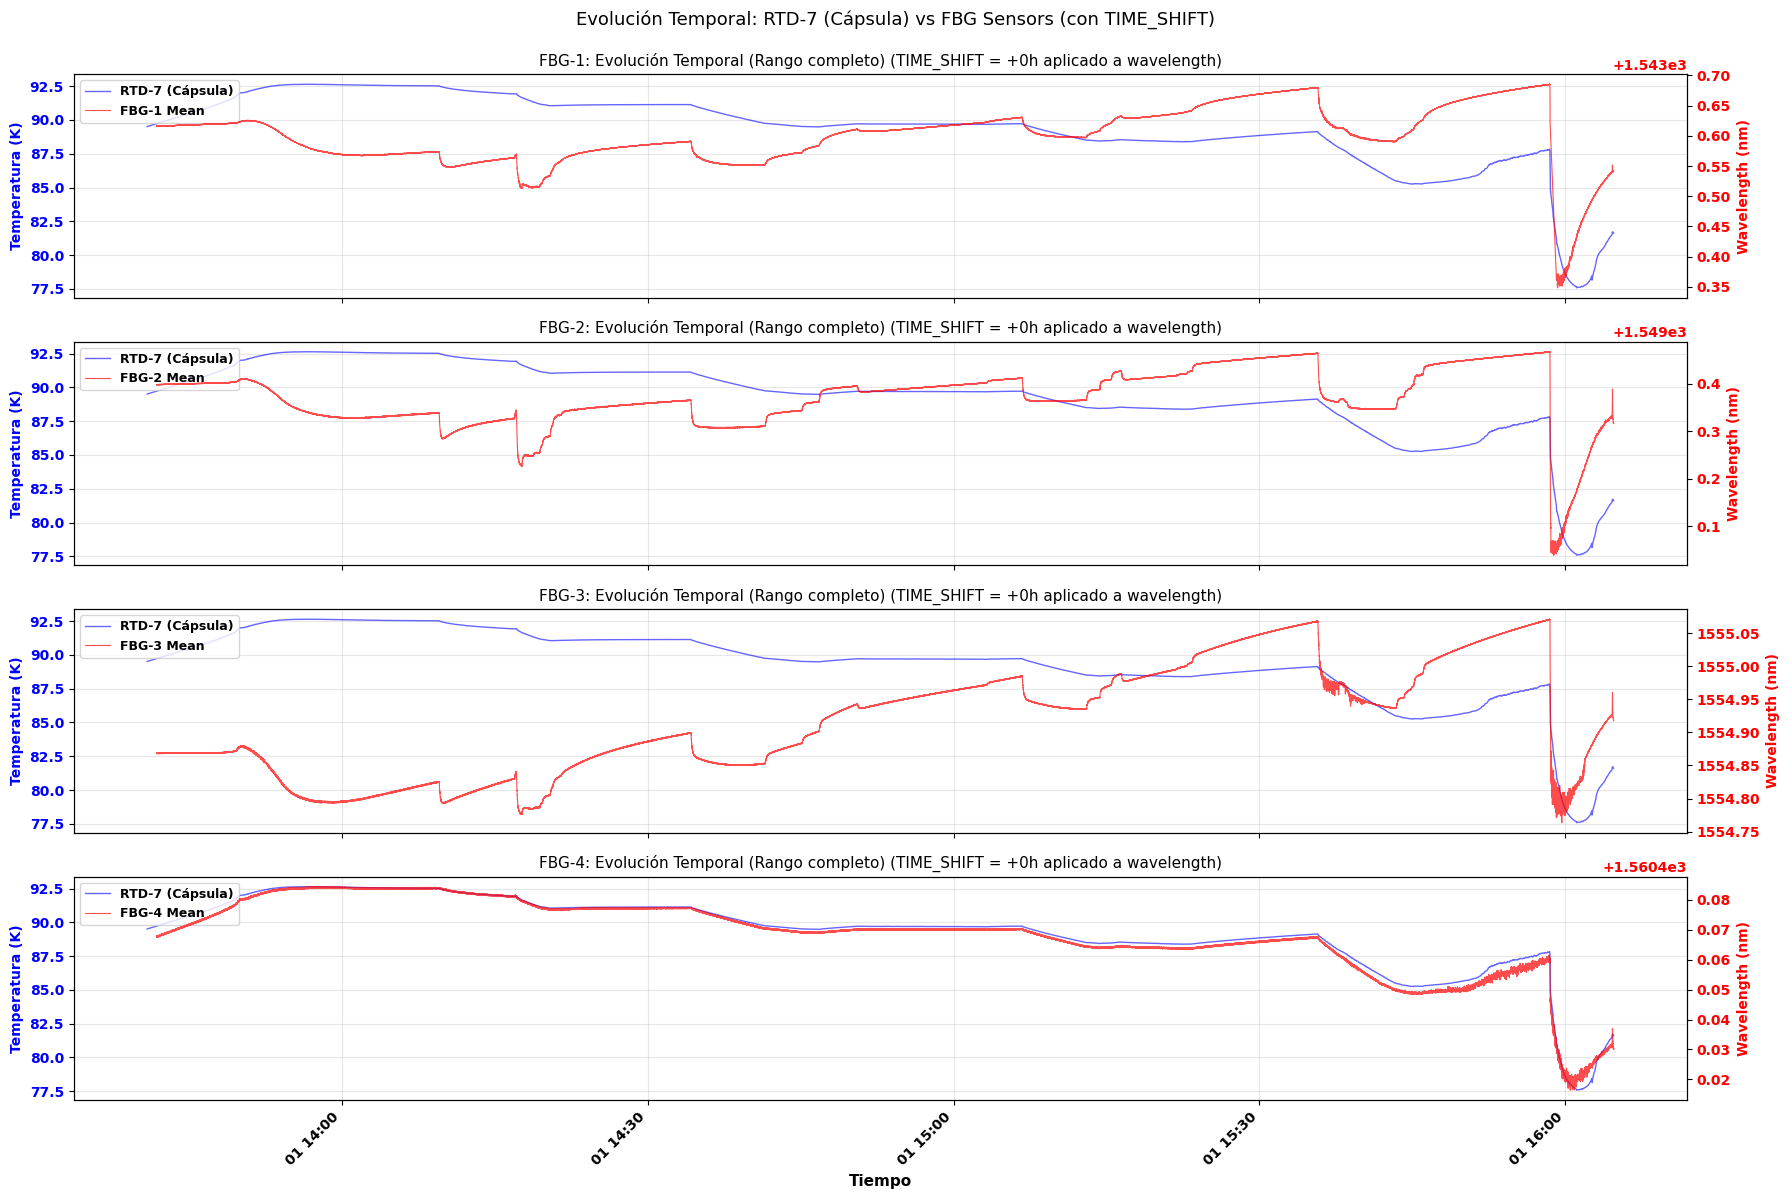


📊 Rango temporal mostrado: (Rango completo)
   Temperatura: 2026-07-01 13:40 - 16:04
   Wavelength (con +0h shift): 2026-07-01 13:41 - 16:04

💡 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'


In [21]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = False  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(10, 12))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(16, 15))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3, 4]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

✅ Espectro cargado: TTree 'spectrum;2'
   Shape spectrum wav: (13, 2, 1, 39200)


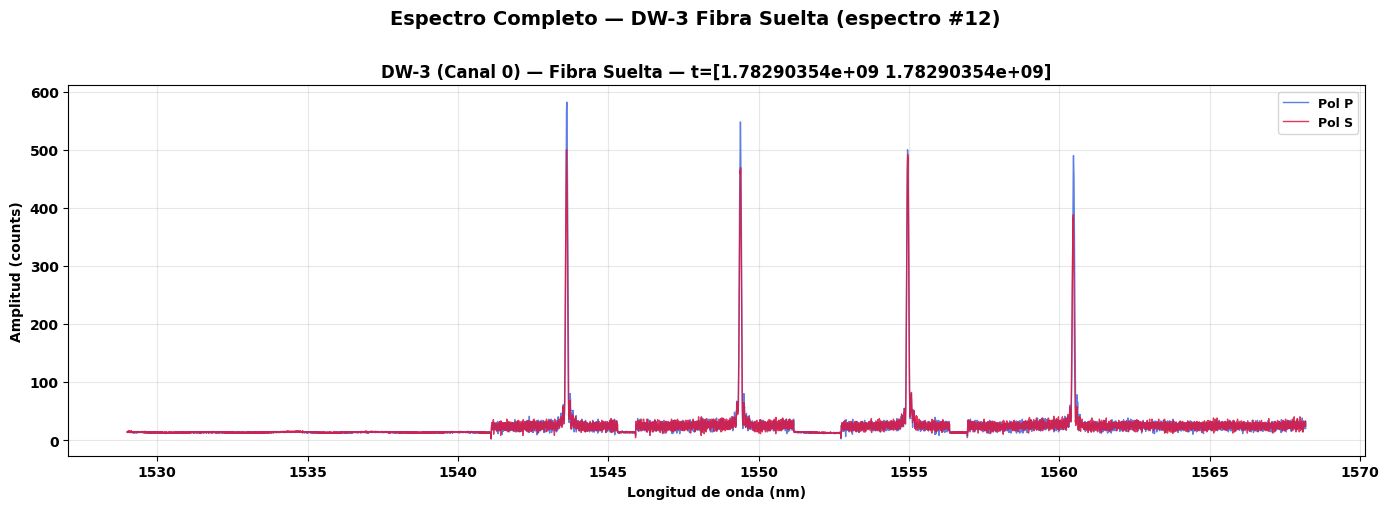


📊 ANÁLISIS PRELIMINAR DEL ESPECTRO DW-3 (espectro #12)
   Resolución del eje λ: Δλ = 1.00 pm/punto (39200 puntos en 39.2 nm)

  ── DW-3 (Fibra Suelta) ──────────────────────────────────────────────────
  Picos detectados: Pol P = 5, Pol S = 4
  Amplitudes Pol P:
    FBG-1: λ = 1543.623 nm,  Amp = 582 counts
    FBG-2: λ = 1549.397 nm,  Amp = 548 counts
    FBG-3: λ = 1549.512 nm,  Amp = 80 counts
    FBG-4: λ = 1554.956 nm,  Amp = 500 counts
    FBG-5: λ = 1560.475 nm,  Amp = 490 counts
  Rango amplitudes: 80 – 582 counts (ratio max/min = 7.28×)
  Espaciado entre sensores:
    FBG-1 → FBG-2: Δλ = 5.773 nm
    FBG-2 → FBG-3: Δλ = 0.115 nm
    FBG-3 → FBG-4: Δλ = 5.444 nm
    FBG-4 → FBG-5: Δλ = 5.519 nm
  Espaciado medio: 4.213 ± 2.369 nm


In [22]:
# ══════════════════════════════════════════════════════════════════════
# ESPECTRO COMPLETO: Fibra DW-3 (fibra suelta)
# ══════════════════════════════════════════════════════════════════════
# Carga el TTree "spectrum" del archivo ROOT y muestra el espectro
# completo de la fibra DW-3 para ambas polarizaciones (P y S).
# ══════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks

# ── 1. Cargar datos de espectro desde el archivo ROOT ──
try:
    with uproot.open(filepath) as file_spec:
        # Buscar el TTree "spectrum" (puede tener ciclos ;1, ;2, etc.)
        spec_keys = [k for k in file_spec.keys() if k.split(";")[0] == "spectrum"]
        if not spec_keys:
            raise KeyError("No se encontró el TTree 'spectrum' en el archivo")
        key_spectrum = sorted(spec_keys, key=lambda k: int(k.split(";")[1]))[-1]
        data_spectrum = file_spec[key_spectrum].arrays(library="np")
        print(f"✅ Espectro cargado: TTree '{key_spectrum}'")
        print(f"   Shape spectrum wav: {data_spectrum['wav'].shape}")
except KeyError as e:
    data_spectrum = None
    print(f"⚠️  {e}")
    print("   Este archivo ROOT no contiene datos de espectro.")
except Exception as e:
    data_spectrum = None
    print(f"❌ Error al cargar espectro: {e}")

# ── 2. Visualización del espectro de DW-3 ──
if data_spectrum is not None:
    spectrum_wav = data_spectrum['wav']
    spectrum_t   = data_spectrum['t']

    n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape
    idx_espectro = min(50, n_espectros - 1)

    # ── Constantes de conversión idx → λ (FAZT I4G-16) ──
    _lam_start = 1529.0   # nm
    _lam_end   = 1568.2   # nm
    _dlam      = (_lam_end - _lam_start) / (n_puntos - 1)   # nm/pt
    wavelength_axis = np.linspace(_lam_start, _lam_end, n_puntos)

    # Canal de DW-3 (canal 0 en este setup de fibra única o canal 0 de 3-fibras)
    ch_dw3 = 0
    pol_labels = ['Pol P', 'Pol S']
    pol_colors = ['royalblue', 'crimson']

    # ── Plot del espectro ──
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    for idx_pol in range(n_pol):
        signal = spectrum_wav[idx_espectro, idx_pol, ch_dw3, :]
        ax.plot(wavelength_axis, signal, label=pol_labels[idx_pol],
                linewidth=1.0, alpha=0.85, color=pol_colors[idx_pol])

    # Convertir timestamp a string legible y aplicar TIME_SHIFT
    t_val = spectrum_t[idx_espectro, 0]
    t_dt = datetime.datetime.fromtimestamp(float(t_val), tz=TZ_VALENCIA).replace(tzinfo=None)
    t_dt_shifted = t_dt + TIME_SHIFT
    t_str = t_dt_shifted.strftime("%Y-%m-%d %H:%M:%S")

    ax.set_title(f'DW-3 (Canal {ch_dw3}) — Fibra Suelta — t = {t_str} (shift aplicado)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitud de onda (nm)', fontsize=10)
    ax.set_ylabel('Amplitud (counts)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.suptitle(f'Espectro Completo — DW-3 Fibra Suelta (espectro #{idx_espectro})',
                 fontsize=14, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════
    # ANÁLISIS PRELIMINAR: Amplitudes y Espaciado
    # ══════════════════════════════════════════════════════════════════
    print(f"\n{''.join(['=']*90)}")
    print(f"📊 ANÁLISIS PRELIMINAR DEL ESPECTRO DW-3 (espectro #{idx_espectro} — t = {t_str})")
    print(f"{''.join(['=']*90)}")
    print(f"   Resolución del eje λ: Δλ = {_dlam*1e3:.2f} pm/punto ({n_puntos} puntos en {_lam_end-_lam_start:.1f} nm)")

    sig_p = spectrum_wav[idx_espectro, 0, ch_dw3, :]
    sig_s = spectrum_wav[idx_espectro, 1, ch_dw3, :]

    # Detección rápida de picos
    sig_max = max(sig_p.max(), sig_s.max())
    peaks_p, _ = find_peaks(sig_p, prominence=sig_max * 0.10, distance=50,
                            height=sig_max * 0.05)
    peaks_s, _ = find_peaks(sig_s, prominence=sig_max * 0.10, distance=50,
                            height=sig_max * 0.05)

    print(f"\n  ── DW-3 (Fibra Suelta) {''.join(['─']*50)}")
    print(f"  Picos detectados: Pol P = {len(peaks_p)}, Pol S = {len(peaks_s)}")

    # Amplitudes de picos (Pol P como referencia)
    if len(peaks_p) > 0:
        amps = sig_p[peaks_p]
        lams = wavelength_axis[peaks_p]
        amp_max, amp_min = amps.max(), amps.min()
        amp_ratio = amp_max / amp_min if amp_min > 0 else np.inf

        print(f"  Amplitudes Pol P:")
        for j, (pk, amp, lam) in enumerate(zip(peaks_p, amps, lams)):
            print(f"    FBG-{j+1}: λ = {lam:.3f} nm,  Amp = {amp:.0f} counts")
        print(f"  Rango amplitudes: {amp_min:.0f} – {amp_max:.0f} counts "
              f"(ratio max/min = {amp_ratio:.2f}×)")

        # Espaciado entre sensores consecutivos
        if len(peaks_p) > 1:
            deltas = np.diff(lams)
            print(f"  Espaciado entre sensores:")
            for j in range(len(deltas)):
                print(f"    FBG-{j+1} → FBG-{j+2}: Δλ = {deltas[j]:.3f} nm")
            print(f"  Espaciado medio: {np.mean(deltas):.3f} ± {np.std(deltas):.3f} nm")


📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (DW-3, 01/07/2026)

✅ Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

📊 Estructura de datos:
   't': shape=(1, 2), dtype=float64
   'wav': shape=(1, 2, 1, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (1, 2, 1, 39200)
      → Dimensiones: (n_entries=1, dim1=2, dim2=1, n_points=39200)

   ⏰ Timestamps ('t'):
      Shape: (1, 2)
      Primeros valores: [1.78290352e+09 1.78290352e+09]

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   ✅ Usando timestamps de 'spectrum.t'
   Timestamps shape: (13, 2) → usando columna 0
   Tiempo objetivo:     2026-07-01 14:15:00
   Tiempo más cercano:  2026-07-01 12:59:02
   Diferencia:          4557.3 segundos
   Índice del evento:   12

📊 Datos cargados del tree 'spectrum':
   Shape raw: (1, 2, 1, 39200)
   → Estructura 4D detectada, extrayendo primera entrada: (2, 1, 39200)

📊 Datos del evento listo para procesar:
   Shape final: (2, 1, 39200)
   Tamaño total

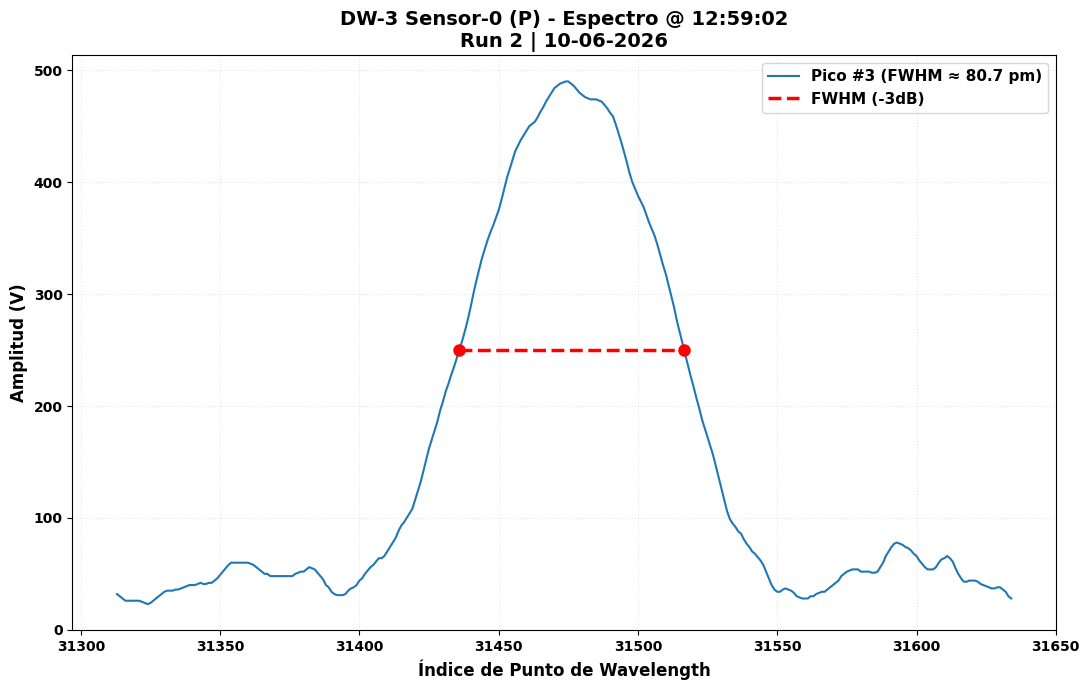


✅ Plot generado exitosamente


In [23]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 7, 1, 14, 15, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 3    # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (DW-3, 01/07/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"DW-3 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        # Extraer valores escalares (results_half retorna arrays, tomamos primer elemento)
        fwhm_height = results_half[1][0] if hasattr(results_half[1], '__len__') else results_half[1]
        fwhm_left = results_half[2][0] if hasattr(results_half[2], '__len__') else results_half[2]
        fwhm_right = results_half[3][0] if hasattr(results_half[3], '__len__') else results_half[3]
        
        plt.hlines(fwhm_height, fwhm_left, fwhm_right, 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([fwhm_left, fwhm_right], [fwhm_height, fwhm_height], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\nRun 2 | 10-06-2026", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\nRun 2 | 10-06-2026", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")